# IMPORTACIÓN DE LIBRERÍAS:

Antes de ejecutar el notebook, ejecuta los siguientes comandos uno por uno:
```bash
pip install numpy
pip install matplotlib
pip install scipy
pip install pandas
pip install openpyxl
```

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.integrate import quad
import math, scipy.optimize
import os
import pandas as pd
import scipy.stats as sp
import statistics as sts

# IMPORTACIÓN DE DATOS

En la siguiente celda debes indicar la ruta de la carpeta donde se encuentran 
los archivos Excel (.xlsx) de tus estaciones hidrometeorológicas.

Modifica únicamente la variable `direccion` con la ruta correspondiente en tu computadora.

**Ejemplo en Windows:**
```
direccion = 'C:/Users/TuNombre/Desktop/ESTACIONES'
```
**Ejemplo en Mac/Linux:**
```
direccion = '/Users/TuNombre/Desktop/ESTACIONES'
```

Asegúrate de que la carpeta contenga únicamente archivos `.xlsx` con el formato de datos descrito en la carpeta `ESTACIONES_PROCESADAS` del repositorio: https://github.com/josephrub/Metodos-estadisticos-en-hidrologia-con-Python.git

In [2]:
# ---------------------------------------------------------------
# MODIFICA ESTA RUTA con la ubicación de tu carpeta de estaciones
# ---------------------------------------------------------------
direccion = 'C:/JOSEPH/LIBRO-CODIGO_DE_ANALISIS_ESTADISTICO/ESTACIONES_PROCESADAS'

# Lee todos los archivos .xlsx dentro de la carpeta indicada
contenido = os.listdir(direccion)
estaciones = []
for fichero in contenido:
    if os.path.isfile(os.path.join(direccion, fichero)) and fichero.endswith('.xlsx'):
        estaciones.append(fichero)

# Muestra la lista de estaciones detectadas
Lista_Estaciones_Procesadas=pd.DataFrame(estaciones,columns=["ARCHIVO"])
Lista_Estaciones_Procesadas.index.name = "ID"
Lista_Estaciones_Procesadas

,ARCHIVO
ID,
0,CANTA_CO.xlsx
1,OXAPAMPA_CO.xlsx
2,PACHAMACHAY_CO.xlsx
3,PIRCA_CO.xlsx
4,YANTAC_CO.xlsx


Selección de estación:

Una vez detectadas las estaciones, ingresa el número de la columna **ID** 
correspondiente a la estación que deseas analizar.

In [3]:
# Ingresa el ID de la estación que deseas analizar
estacion_seleccionada = input("Ingrese el ID de la estación: ")

# Obtiene el nombre del archivo correspondiente
estacion_elegida = Lista_Estaciones_Procesadas.loc[int(estacion_seleccionada), "ARCHIVO"]

print(f"Estación seleccionada: {estacion_elegida}")

Estación seleccionada: PIRCA_CO.xlsx


# ESTACIÓN ELEGIDA

En la siguiente celda modifica la variable `carpeta_salida` con la ruta 
de la carpeta donde deseas guardar los resultados del análisis.

**Ejemplo en Windows:**
```
carpeta_salida = 'C:/Users/TuNombre/Desktop/RESULTADOS'
```
**Ejemplo en Mac/Linux:**
```
carpeta_salida = '/Users/TuNombre/Desktop/RESULTADOS'
```
Se creará automáticamente una subcarpeta con el nombre de la estación seleccionada dentro de la ruta indicada.

In [4]:
# ---------------------------------------------------------------
# MODIFICA ESTA RUTA con la ubicación de tu carpeta de resultados
# ---------------------------------------------------------------
carpeta_salida = 'C:/JOSEPH/LIBRO-CODIGO_DE_ANALISIS_ESTADISTICO'

# Extrae el nombre y categoría de la estación seleccionada
estacion_categoria = estacion_elegida.split("_")
estacion_e = estacion_categoria[0]
categoria_e = estacion_categoria[1].split(".")[0]

# Crea la subcarpeta de resultados para la estación elegida
ubi_carpeta = os.path.join(carpeta_salida, f'ANALISIS_{estacion_e}_{categoria_e}')
os.makedirs(ubi_carpeta, exist_ok=True)

print(f"Carpeta de resultados: {ubi_carpeta}")

Carpeta de resultados: C:/JOSEPH/LIBRO-CODIGO_DE_ANALISIS_ESTADISTICO\ANALISIS_PIRCA_CO


## Lectura de datos de la estación:

A continuación se carga el archivo Excel de la estación seleccionada 
desde la carpeta indicada anteriormente.

In [5]:
# Lee el archivo Excel de la estación seleccionada
data = pd.read_excel(os.path.join(direccion, estacion_elegida))

# Renombra la primera columna como 'Año' y la establece como índice
data.columns.values[0] = 'Año'
data.set_index('Año', inplace=True)

data

,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Setiembre,Octubre,Noviembre,Diciembre
Año,,,,,,,,,,,,
1967,NaN,NaN,NaN,NaN,4.2,1.3,0.0,1.2,1.2,12.8,8.2,3.6
1968,5.8,8.2,10.4,4.1,0.0,0.0,0.0,1.4,0.0,6.7,4.7,9.6
1969,4.6,10.5,9.9,6.8,0.0,0.0,0.0,0.0,1.5,2.8,4.0,14.8
1970,17.8,5.8,9.5,3.6,6.9,0.0,0.0,0.0,2.9,4.1,3.7,4.7
1971,2.8,5.9,11.6,1.7,0.0,0.0,0.0,0.0,0.0,2.5,0.0,6.3
1972,7.1,18.5,15.4,19.8,0.0,0.0,0.0,0.0,0.0,1.3,0.0,19.4
1973,19.3,17.4,13.8,16.3,0.0,0.0,0.0,0.0,0.0,9.2,4.7,9.1
1974,10.1,12.3,9.7,6.2,0.0,0.0,0.0,0.0,0.0,2.6,0.0,0.0
1975,11.0,11.6,10.8,8.1,4.7,5.3,0.0,0.0,0.0,0.0,0.0,9.3


## Depuración y estadísticos básicos de la tabla de datos:

Se identifican y eliminan los valores no disponibles (S/D) o vacíos, 
se calcula el máximo anual de precipitación y se agregan filas resumen 
con el máximo, promedio y mínimo mensual al final de la tabla.

In [6]:
# Recarga el archivo Excel de la estación para evitar datos residuales
data = pd.read_excel(os.path.join(direccion, estacion_elegida))
data.columns.values[0] = 'Año'
data.set_index('Año', inplace=True)

# Reemplaza valores 'S/D' y variantes por NaN
Meses = list(data.columns)
for mes in Meses:
    data[mes] = data[mes].astype(str).str.strip()
    data[mes] = data[mes].replace({'S/D': np.nan, 'nan': np.nan,
                                    'None': np.nan, '': np.nan})
    data[mes] = pd.to_numeric(data[mes], errors='coerce')

# Dimensiones del dataset original (solo meses, sin Max)
Años        = list(data.index)
n_data      = data[Meses].shape[0] * data[Meses].shape[1]

# --- Máximo anual por fila ---
columna_max = []
for Año in Años:
    data_fila_año = data.loc[Año]
    data_max      = data_fila_año.max()
    columna_max.append(0 if np.isnan(data_max) else data_max)

data["Max"] = columna_max

# --- Estadísticos por columna (solo meses, sin Max) ---
fila_max        = []
fila_promedio   = []
fila_min        = []
n_data_depurada = 0

for mes in Meses:  # ← solo itera sobre meses
    mes_columna = data[mes].dropna()
    fila_promedio.append(round(mes_columna.mean(), 2))
    fila_min.append(mes_columna.min())
    fila_max.append(mes_columna.max())
    n_data_depurada += mes_columna.size

# Agrega Max a las filas de resumen
fila_max_max      = data["Max"].max()
fila_promedio_max = round(data["Max"].mean(), 2)
fila_min_max      = data["Max"].min()

fila_max.append(fila_max_max)
fila_promedio.append(fila_promedio_max)
fila_min.append(fila_min_max)

# --- Resumen ---
print(f"Existen {n_data - n_data_depurada} elementos S/D o vacíos")

data.loc["MAXIMO"]   = fila_max
data.loc["PROMEDIO"] = fila_promedio
data.loc["MINIMO"]   = fila_min

Existen 15 elementos S/D o vacíos


In [7]:
data

,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Setiembre,Octubre,Noviembre,Diciembre,Max
Año,,,,,,,,,,,,,
1967,NaN,NaN,NaN,NaN,4.20,1.30,0.00,1.20,1.20,12.8,8.2,3.60,12.80
1968,5.8,8.20,10.40,4.10,0.00,0.00,0.00,1.40,0.00,6.7,4.7,9.60,10.40
1969,4.6,10.50,9.90,6.80,0.00,0.00,0.00,0.00,1.50,2.8,4.0,14.80,14.80
1970,17.8,5.80,9.50,3.60,6.90,0.00,0.00,0.00,2.90,4.1,3.7,4.70,17.80
1971,2.8,5.90,11.60,1.70,0.00,0.00,0.00,0.00,0.00,2.5,0.0,6.30,11.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024,17.7,10.60,20.00,10.10,3.20,0.00,0.00,0.50,9.00,6.0,14.6,15.70,20.00
2025,12.3,32.00,19.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.00
MAXIMO,20.8,32.00,24.50,25.90,12.50,5.30,1.70,13.40,15.30,17.8,20.8,43.80,43.80


## Factores de ajuste según el número de observaciones

In [8]:
# Factores de ajuste por número de observaciones diarias
factores_ajuste = {
    1: 1.13,  2: 1.04,
    **{n: 1.03 for n in range(3, 5)},
    **{n: 1.02 for n in range(5, 9)},
    **{n: 1.01 for n in range(9, 25)},
    **{n: 1.00 for n in range(25, 101)}  # valores >= 25 se les asigna factor 1.00
}

tabla_factores_ajuste = pd.DataFrame.from_dict(
    factores_ajuste, orient="index", columns=["Factor de ajuste"]
)
tabla_factores_ajuste.index.name = "Número de observaciones/día"

In [9]:
tabla_factores_ajuste

,Factor de ajuste
Número de observaciones/día,
1,1.13
2,1.04
3,1.03
4,1.03
5,1.02
...,...
96,1.00
97,1.00
98,1.00


## Serie de máximos anuales

Se extrae la serie de precipitaciones máximas anuales

In [10]:
# Extrae la serie de máximos anuales excluyendo las filas de resumen
ld_m = data["Max"].iloc[:-3].tolist()
ld_i = data.index[:-3].tolist()

In [11]:
# Identifica el mes en que ocurrió el máximo anual para cada año
ld_mes = [
    data.loc[a_i][data.loc[a_i] == data["Max"][a_i]].index[0]
    for a_i in ld_i
]

ld_mes

['Octubre',
 'Marzo',
 'Diciembre',
 'Enero',
 'Marzo',
 'Abril',
 'Enero',
 'Febrero',
 'Febrero',
 'Marzo',
 'Enero',
 'Marzo',
 'Marzo',
 'Diciembre',
 'Noviembre',
 'Diciembre',
 'Abril',
 'Marzo',
 'Marzo',
 'Enero',
 'Febrero',
 'Marzo',
 'Marzo',
 'Diciembre',
 'Noviembre',
 'Marzo',
 'Marzo',
 'Enero',
 'Diciembre',
 'Febrero',
 'Diciembre',
 'Febrero',
 'Febrero',
 'Diciembre',
 'Marzo',
 'Febrero',
 'Enero',
 'Diciembre',
 'Marzo',
 'Diciembre',
 'Marzo',
 'Diciembre',
 'Diciembre',
 'Enero',
 'Abril',
 'Diciembre',
 'Febrero',
 'Noviembre',
 'Noviembre',
 'Febrero',
 'Febrero',
 'Enero',
 'Marzo',
 'Febrero',
 'Enero',
 'Diciembre',
 'Marzo',
 'Marzo',
 'Febrero']

In [12]:
# Construye la tabla de precipitaciones máximas anuales
precipitaciones_maximas = pd.DataFrame({
    "Año": ld_i,
    "Mes": ld_mes,
    "Pp max. 24 horas (mm)": ld_m
}, index=range(1, len(ld_i) + 1))

precipitaciones_maximas.index.name = "N°"

precipitaciones_maximas

,Año,Mes,Pp max. 24 horas (mm)
N°,,,
1,1967,Octubre,12.8
2,1968,Marzo,10.4
3,1969,Diciembre,14.8
4,1970,Enero,17.8
5,1971,Marzo,11.6
6,1972,Abril,19.8
7,1973,Enero,19.3
8,1974,Febrero,12.3
9,1975,Febrero,11.6


## Corrección de precipitación máxima

Se aplica el factor de ajuste correspondiente al número de observaciones 
diarias del pluviómetro de la estación. Modifica únicamente la variable 
`n_nod` según el equipo de medición utilizado.

In [13]:
# ---------------------------------------------------------------
# MODIFICA ESTE VALOR según el número de observaciones/día
# de la estación (revisa la tabla de factores de ajuste anterior)
# ---------------------------------------------------------------
n_obs = 1

# Aplica el factor de corrección a la serie de máximos
factor_c = tabla_factores_ajuste.loc[n_obs, "Factor de ajuste"]

precipitaciones_maximas_corregidas = precipitaciones_maximas.copy()
precipitaciones_maximas_corregidas["Pp max. 24 horas corregido (mm)"] = (
    precipitaciones_maximas_corregidas["Pp max. 24 horas (mm)"] * factor_c
)

# Fila con el máximo de toda la serie
idx_max = precipitaciones_maximas_corregidas["Pp max. 24 horas corregido (mm)"].idxmax()
fila_max = precipitaciones_maximas_corregidas.loc[idx_max]

print("Precipitación máxima en 24 horas")
print("─" * 35)
print(f"Año            : {int(fila_max['Año'])}")
print(f"Mes            : {fila_max['Mes']}")
print(f"Pp original    : {fila_max['Pp max. 24 horas (mm)']:.2f} mm")
print(f"Pp corregida   : {fila_max['Pp max. 24 horas corregido (mm)']:.2f} mm")
print(f"Factor aplicado: {factor_c}")

Precipitación máxima en 24 horas
───────────────────────────────────
Año            : 1997
Mes            : Diciembre
Pp original    : 43.80 mm
Pp corregida   : 49.49 mm
Factor aplicado: 1.13


In [14]:
# Tabla de precipitaciones máximas en 24 horas corregidas
precipitaciones_maximas_corregidas

,Año,Mes,Pp max. 24 horas (mm),Pp max. 24 horas corregido (mm)
N°,,,,
1,1967,Octubre,12.8,14.464
2,1968,Marzo,10.4,11.752
3,1969,Diciembre,14.8,16.724
4,1970,Enero,17.8,20.114
5,1971,Marzo,11.6,13.108
6,1972,Abril,19.8,22.374
7,1973,Enero,19.3,21.809
8,1974,Febrero,12.3,13.899
9,1975,Febrero,11.6,13.108


## Análisis de datos dudosos

In [15]:
# Prepara la tabla para el análisis de datos dudosos
serie_pp = precipitaciones_maximas_corregidas.copy()
serie_pp = serie_pp.drop(columns=["Mes", "Pp max. 24 horas corregido (mm)"])

# Calcula el logaritmo base 10 (vacío si el valor es cero)
lista_precipitaciones = serie_pp["Pp max. 24 horas (mm)"]

serie_pp["Log10 Pp max. 24 horas (mm)"] = [
    round(math.log10(pp), 4) if pp > 0 else ""
    for pp in lista_precipitaciones
]

serie_pp

,Año,Pp max. 24 horas (mm),Log10 Pp max. 24 horas (mm)
N°,,,
1,1967,12.8,1.1072
2,1968,10.4,1.0170
3,1969,14.8,1.1703
4,1970,17.8,1.2504
5,1971,11.6,1.0645
6,1972,19.8,1.2967
7,1973,19.3,1.2856
8,1974,12.3,1.0899
9,1975,11.6,1.0645


In [16]:
# Estadísticos de la serie logarítmica:

# Filtra valores vacíos y convierte a lista numérica
lista_log = [v for v in serie_pp["Log10 Pp max. 24 horas (mm)"] if v != ""]

n          = len(lista_log)
media      = sum(lista_log) / n
var        = sum((v - media) ** 2 for v in lista_log) / (n - 1)
desvest    = math.sqrt(var)

print("Estadísticos de Log10 Pp max. 24 horas")
print("─" * 40)
print(f"N° de datos      : {n}")
print(f"Media            : {media:.4f}")
print(f"Desv. estándar   : {desvest:.4f}")

Estadísticos de Log10 Pp max. 24 horas
────────────────────────────────────────
N° de datos      : 59
Media            : 1.2591
Desv. estándar   : 0.1244


In [17]:
# Tamaños de muestra y valores críticos Kn (Bulletin 17B, IACWD, 1982)
tamaños_muestra = list(range(10, 51)) + list(range(55, 101, 5)) + list(range(110, 141, 10))

valores_Kn = [
    2.036, 2.088, 2.134, 2.175, 2.213, 2.247, 2.279, 2.309, 2.335, 2.361,
    2.385, 2.408, 2.429, 2.448, 2.467, 2.486, 2.502, 2.519, 2.534, 2.549,
    2.563, 2.577, 2.591, 2.604, 2.616, 2.628, 2.639, 2.650, 2.661, 2.671,
    2.682, 2.692, 2.700, 2.710, 2.719, 2.727, 2.736, 2.744, 2.753, 2.760,
    2.768, 2.804, 2.837, 2.866, 2.893, 2.917, 2.940, 2.961, 2.981, 3.000,
    3.017, 3.049, 3.078, 3.104, 3.129
]

# Construye la tabla de valores críticos
tabla_Kn = pd.DataFrame(
    {"Kn": valores_Kn},
    index=pd.Index(tamaños_muestra, name="Tamaño de muestra n")
)

tabla_Kn

,Kn
Tamaño de muestra n,
10,2.036
11,2.088
12,2.134
13,2.175
14,2.213
15,2.247
16,2.279
17,2.309
18,2.335


In [18]:
# Tamaño de la muestra
K = n  # usa el n calculado en la sección anterior

# Busca el índice más cercano en la tabla
indices_Kn = list(tabla_Kn.index)
n_cercano  = min(indices_Kn, key=lambda i: abs(K - i))

# Obtiene el valor Kn correspondiente
if n_cercano >= K:
    Kn_valor = tabla_Kn.loc[n_cercano, "Kn"]
    print(f"Tamaño de muestra  : {K}")
    print(f"Índice usado       : {n_cercano} (límite superior)")
    print(f"Valor Kn           : {Kn_valor}")
else:
    Kn_valor = tabla_Kn.loc[n_cercano, "Kn"]
    print(f"Tamaño de muestra  : {K}")
    print(f"Índice usado       : {n_cercano} (límite inferior)")
    print(f"Valor Kn           : {Kn_valor}")

Tamaño de muestra  : 59
Índice usado       : 60 (límite superior)
Valor Kn           : 2.837


Se define la función que obtiene el valor crítico Kn para cualquier 
tamaño de muestra mediante interpolación lineal en la tabla de valores.

In [19]:
def interpolar_kn(n_muestra):
    """
    Obtiene el valor crítico Kn para un tamaño de muestra dado.
    Si el valor exacto no está en la tabla, interpola linealmente
    entre los dos valores más cercanos.

    Parámetros
    ----------
    n_muestra : int
        Tamaño de la muestra.

    Retorna
    -------
    float
        Valor crítico Kn interpolado.
    """
    # Determina el paso de interpolación según el rango del tamaño de muestra
    if n_muestra <= 50:
        paso = 1
    elif n_muestra <= 100:
        paso = 5
    else:
        paso = 10

    # Si el valor exacto existe en la tabla, lo retorna directamente
    indices = list(tabla_Kn.index)
    if n_muestra in indices:
        return tabla_Kn.loc[n_muestra, "Kn"]

    # Busca los límites inferior y superior para interpolar
    n_cercano = min(indices, key=lambda i: abs(n_muestra - i))

    if n_cercano > n_muestra:
        n_sup = n_cercano
        n_inf = n_cercano - paso
    else:
        n_inf = n_cercano
        n_sup = n_cercano + paso

    kn_inf = tabla_Kn.loc[n_inf, "Kn"]
    kn_sup = tabla_Kn.loc[n_sup, "Kn"]

    # Interpolación lineal
    return kn_inf + (n_muestra - n_inf) * (kn_sup - kn_inf) / (n_sup - n_inf)

Se calculan los límites superior e inferior para la identificación de datos dudosos en la serie.

In [20]:
# Obtiene el valor Kn para el tamaño de la muestra
kn_analisis = interpolar_kn(n)

# Calcula los límites en escala logarítmica
Yl_superior = media + desvest * kn_analisis
Yl_inferior = media - desvest * kn_analisis

# Convierte los límites a escala original (mm)
limite_superior = 10 ** Yl_superior
limite_inferior = 10 ** Yl_inferior

print("Detección de datos dudosos")
print("─" * 27)
print(f"Valor Kn         : {kn_analisis:.4f}")
print(f"Límite superior  : {limite_superior:.2f} mm")
print(f"Límite inferior  : {limite_inferior:.2f} mm")

Detección de datos dudosos
───────────────────────────
Valor Kn         : 2.8304
Límite superior  : 40.86 mm
Límite inferior  : 8.07 mm


In [21]:
# Tabla resumen de estadísticos y límites de datos dudosos
tabla_datos_dudosos = pd.DataFrame({
    "Valor": [media, desvest, n, kn_analisis,
              Yl_superior, Yl_inferior, limite_superior, limite_inferior]
}, index=pd.Index([
    "Media", "Desviación estándar", "n", "Kn",
    "YL (superior)", "YL (inferior)",
    "Límite superior (mm)", "Límite inferior (mm)"
], name="Parámetro"))

tabla_datos_dudosos

,Valor
Parámetro,
Media,1.259081
Desviación estándar,0.124443
n,59.000000
Kn,2.830400
YL (superior),1.611304
YL (inferior),0.906859
Límite superior (mm),40.860487
Límite inferior (mm),8.069733


Se eliminan los datos dudosos identificados en la sección anterior y se prepara la serie depurada para el análisis de frecuencia.

In [22]:
# Copia la tabla corregida y elimina la columna de mes
serie_frecuencia = precipitaciones_maximas_corregidas.copy()
serie_frecuencia = serie_frecuencia.drop(columns=["Mes"])

# Elimina los datos fuera de los límites de datos dudosos
serie_frecuencia = serie_frecuencia[
    serie_frecuencia["Pp max. 24 horas (mm)"].between(limite_inferior, limite_superior)
]

# Reinicia el índice desde 0
serie_frecuencia.index = range(0, len(serie_frecuencia))
serie_frecuencia.index.name = "N°"

serie_frecuencia

,Año,Pp max. 24 horas (mm),Pp max. 24 horas corregido (mm)
N°,,,
0,1967,12.8,14.464
1,1968,10.4,11.752
2,1969,14.8,16.724
3,1970,17.8,20.114
4,1971,11.6,13.108
5,1972,19.8,22.374
6,1973,19.3,21.809
7,1974,12.3,13.899
8,1975,11.6,13.108


Se eliminan los valores iguales a cero, se renombra la columna de precipitaciones corregidas y se calcula el logaritmo base 10 de la serie.

In [23]:
# Elimina registros con precipitación corregida igual a cero
serie_frecuencia = serie_frecuencia[
    serie_frecuencia["Pp max. 24 horas corregido (mm)"] != 0
]

# Elimina columna original y renombra la corregida
serie_frecuencia = serie_frecuencia.drop(columns=["Pp max. 24 horas (mm)"])
serie_frecuencia = serie_frecuencia.rename(columns={
    "Pp max. 24 horas corregido (mm)": "Pp max. 24 horas (mm)"
})

# Calcula el logaritmo base 10 de la serie
pp_24h = serie_frecuencia["Pp max. 24 horas (mm)"]

serie_frecuencia["Log10 Pp max. 24 horas (mm)"] = [
    round(math.log10(pp), 4) if pp > 0 else ""
    for pp in pp_24h
]

# Reinicia el índice
serie_frecuencia = serie_frecuencia.reset_index(drop=True)

serie_frecuencia

,Año,Pp max. 24 horas (mm),Log10 Pp max. 24 horas (mm)
0,1967,14.464,1.1603
1,1968,11.752,1.0701
2,1969,16.724,1.2233
3,1970,20.114,1.3035
4,1971,13.108,1.1175
5,1972,22.374,1.3497
6,1973,21.809,1.3386
7,1974,13.899,1.1430
8,1975,13.108,1.1175
9,1976,19.097,1.2810


# PRUEBA DE BONDAD DE AJUSTE

Se calculan los estadísticos básicos de la serie de precipitaciones máximas anuales en escala original y logarítmica.

In [24]:
# Serie de valores
pp_24h      = serie_frecuencia["Pp max. 24 horas (mm)"]
log_pp_24h  = serie_frecuencia["Log10 Pp max. 24 horas (mm)"]
n_frecuencia = len(pp_24h)

# Media
media_pp     = np.mean(pp_24h)
media_log_pp = np.mean(log_pp_24h)

# Desviación estándar
desvest_pp     = pp_24h.std()
desvest_log_pp = log_pp_24h.std()

# Coeficiente de asimetría
sesgo_pp     = sp.skew(pp_24h, bias=False)
sesgo_log_pp = sp.skew(log_pp_24h, bias=False)

# Coeficiente k (Log-Pearson III)
k_log = sesgo_log_pp / 6

# Tabla resumen de estadísticos en escala original y logarítmica
tabla_estadisticos = pd.DataFrame({
    "Media (μ)"                : [media_pp,     media_log_pp],
    "Desv. estándar (σ)"       : [desvest_pp,   desvest_log_pp],
    "Coef. de asimetría (Cs)"  : [sesgo_pp,     sesgo_log_pp]
}, index=pd.Index(["Original", "Logarítmica"], name="Serie"))

tabla_estadisticos

,Media (μ),Desv. estándar (σ),Coef. de asimetría (Cs)
Serie,,,
Original,20.936172,5.890956,1.239638
Logarítmica,1.305553,0.114663,0.355326


## Prueba de bondad de ajuste de Kolmogorov-Smirnov

Se construye la tabla base para la prueba de Kolmogorov-Smirnov,
ordenando la serie de menor a mayor y calculando la frecuencia 
observada acumulada F₀(Xm).

In [25]:
# Ordena la serie de precipitaciones de menor a mayor
pp_ordenadas = sorted(serie_frecuencia["Pp max. 24 horas (mm)"].tolist())
n_bondad     = len(pp_ordenadas)

# Construye la tabla base con frecuencia observada acumulada
tabla_bondad = pd.DataFrame({
    "Xm (mm)": pp_ordenadas,
    "Fo (Xm)": [i / (n_bondad + 1) for i in range(1, n_bondad + 1)]
}, index=pd.Index(range(1, n_bondad + 1), name="N°"))

tabla_bondad

,Xm (mm),Fo (Xm)
N°,,
1,11.752,0.016949
2,13.108,0.033898
3,13.108,0.050847
4,13.673,0.067797
5,13.899,0.084746
6,14.012,0.101695
7,14.125,0.118644
8,14.238,0.135593
9,14.464,0.152542


In [26]:
# Parámetros de la prueba de Kolmogorov-Smirnov
x_min = tabla_bondad["Xm (mm)"].min()
x_max = tabla_bondad["Xm (mm)"].max()
NC    = 1.33 * math.log(n_bondad) + 1

print("Parámetros de la prueba K-S")
print("─" * 28)
print(f"N° de datos  : {n_bondad}")
print(f"Xm mínimo    : {x_min:.2f} mm")
print(f"Xm máximo    : {x_max:.2f} mm")
print(f"NC           : {NC:.4f}")

Parámetros de la prueba K-S
────────────────────────────
N° de datos  : 58
Xm mínimo    : 11.75 mm
Xm máximo    : 42.37 mm
NC           : 6.4004


### Distribución Normal

Se ajusta la distribución Normal a la serie de precipitaciones máximas
y se calcula el estadístico Delta para la prueba de Kolmogorov-Smirnov.

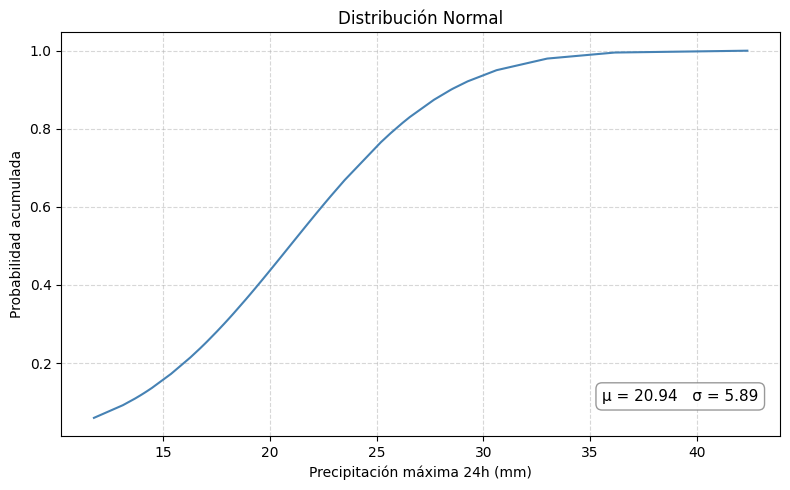

In [27]:
try:
    # Parámetros de la distribución Normal
    mu_n    = tabla_bondad["Xm (mm)"].mean()
    sigma_n = tabla_bondad["Xm (mm)"].std()
    x       = tabla_bondad["Xm (mm)"].tolist()

    # Probabilidad acumulada
    dist_normal = sp.norm(mu_n, sigma_n)
    fp_normal   = dist_normal.cdf(x)

    # Agrega columnas a la tabla de bondad
    tabla_bondad["Normal"]       = fp_normal
    tabla_bondad["Delta Normal"] = abs(tabla_bondad["Normal"] - tabla_bondad["Fo (Xm)"])


# Gráfico
    plt.figure(figsize=(8, 5))
    plt.plot(x, fp_normal, color="steelblue", linewidth=1.5)
    plt.title("Distribución Normal")
    plt.xlabel("Precipitación máxima 24h (mm)")
    plt.ylabel("Probabilidad acumulada")
    plt.text(
        0.97, 0.08,
        f"μ = {mu_n:.2f}   σ = {sigma_n:.2f}",
        fontsize=11,
        ha="right", va="bottom",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
    )
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(ubi_carpeta, "Distribucion_Normal.pdf"), dpi=200)
    plt.savefig(os.path.join(ubi_carpeta, "Distribucion_Normal.png"), dpi=200)
    plt.show()

except Exception as e:
    print(f"Error en distribución Normal: {e}")
    tabla_bondad["Normal"]       = 0
    tabla_bondad["Delta Normal"] = 0

### Distribución Log normal 2 Parámetros

Se ajusta la distribución Log normal de 2 parámetros a la serie de 
precipitaciones máximas y se calcula el estadístico Delta para la 
prueba de Kolmogorov-Smirnov.

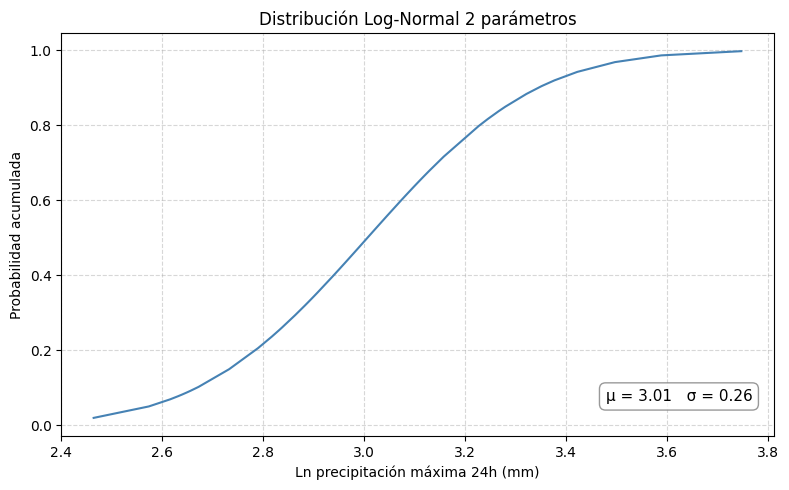

In [28]:
try:
    # Calcula el logaritmo natural de la serie
    tabla_bondad["Ln (Xm)"] = tabla_bondad["Xm (mm)"].apply(math.log)

    # Parámetros de la distribución Log-Normal 2P
    mu_ln    = tabla_bondad["Ln (Xm)"].mean()
    sigma_ln = tabla_bondad["Ln (Xm)"].std()
    x_ln     = tabla_bondad["Ln (Xm)"].tolist()

    # Probabilidad acumulada
    dist_ln2p = sp.norm(mu_ln, sigma_ln)
    fp_ln2p   = dist_ln2p.cdf(x_ln)

    # Agrega columnas a la tabla de bondad
    tabla_bondad["Log Normal 2 Parámetros"]       = fp_ln2p
    tabla_bondad["Delta Log Normal 2 Parámetros"] = abs(
        tabla_bondad["Log Normal 2 Parámetros"] - tabla_bondad["Fo (Xm)"]
    )

    # Gráfico
    plt.figure(figsize=(8, 5))
    plt.plot(x_ln, fp_ln2p, color="steelblue", linewidth=1.5)
    plt.title("Distribución Log-Normal 2 parámetros")
    plt.xlabel("Ln precipitación máxima 24h (mm)")
    plt.ylabel("Probabilidad acumulada")
    plt.text(
        0.97, 0.08,
        f"μ = {mu_ln:.2f}   σ = {sigma_ln:.2f}",
        fontsize=11,
        ha="right", va="bottom",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
    )
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(ubi_carpeta, "Log_Normal_2_Parametros.pdf"), dpi=200)
    plt.savefig(os.path.join(ubi_carpeta, "Log_Normal_2_Parametros.png"), dpi=200)
    plt.show()

except Exception as e:
    print(f"Error en distribución Log-Normal 2P: {e}")
    tabla_bondad["Log Normal 2 Parámetros"]       = 0
    tabla_bondad["Delta Log Normal 2 Parámetros"] = 0

### Distribución Log normal 3 Parámetros

Se ajusta la distribución Log normal de 3 parámetros a la serie de
precipitaciones máximas y se calcula el estadístico Delta para la
prueba de Kolmogorov-Smirnov.

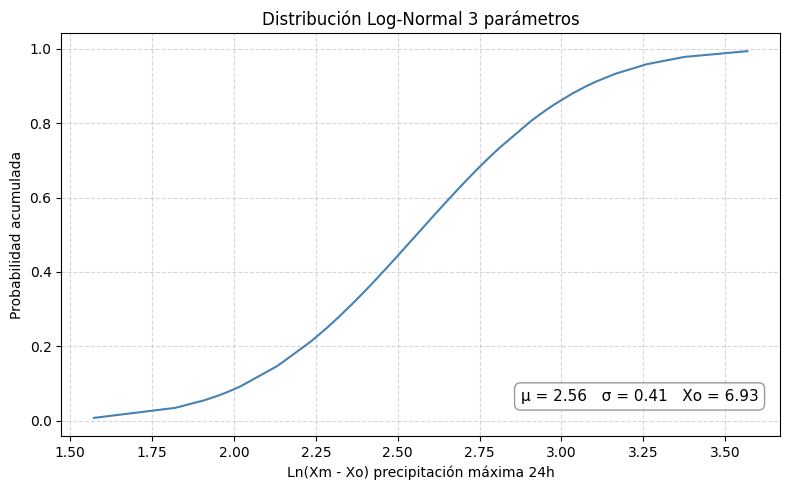

In [29]:
try:
    # Tercer parámetro Xo (método de la mediana)
    x_mediana  = tabla_bondad["Xm (mm)"].median()
    xo_ln3     = (x_min * x_max - x_mediana**2) / (x_min + x_max - 2 * x_mediana)

    # Logaritmo natural de la serie desplazada
    tabla_bondad["Ln (Xm-Xo)"] = tabla_bondad["Xm (mm)"].apply(
        lambda v: math.log(v - xo_ln3)
    )
    x_ln3 = tabla_bondad["Ln (Xm-Xo)"].tolist()

    # Parámetros de la distribución Log-Normal 3P
    mu_ln3    = tabla_bondad["Ln (Xm-Xo)"].mean()
    sigma_ln3 = math.sqrt(tabla_bondad["Ln (Xm-Xo)"].var(ddof=0))

    # Probabilidad acumulada
    dist_ln3p = sp.norm(mu_ln3, sigma_ln3)
    fp_ln3p   = dist_ln3p.cdf(x_ln3)

    # Agrega columnas a la tabla de bondad
    tabla_bondad["Log Normal 3 Parámetros"]       = fp_ln3p
    tabla_bondad["Delta Log Normal 3 Parámetros"] = abs(
        tabla_bondad["Log Normal 3 Parámetros"] - tabla_bondad["Fo (Xm)"]
    )

    # Gráfico
    plt.figure(figsize=(8, 5))
    plt.plot(x_ln3, fp_ln3p, color="steelblue", linewidth=1.5)
    plt.title("Distribución Log-Normal 3 parámetros")
    plt.xlabel("Ln(Xm - Xo) precipitación máxima 24h")
    plt.ylabel("Probabilidad acumulada")
    plt.text(
        0.97, 0.08,
        f"μ = {mu_ln3:.2f}   σ = {sigma_ln3:.2f}   Xo = {xo_ln3:.2f}",
        fontsize=11,
        ha="right", va="bottom",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
    )
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(ubi_carpeta, "Log_Normal_3_Parametros.pdf"), dpi=200)
    plt.savefig(os.path.join(ubi_carpeta, "Log_Normal_3_Parametros.png"), dpi=200)
    plt.show()

except Exception as e:
    print(f"Error en distribución Log-Normal 3P: {e}")
    tabla_bondad["Log Normal 3 Parámetros"]       = 0
    tabla_bondad["Delta Log Normal 3 Parámetros"] = 0

### Distribución Pearson tipo III (Gamma de 3 parámetros)

Se ajusta la distribución Pearson tipo III a la serie de precipitaciones máximas y se calcula el estadístico Delta para la
prueba de Kolmogorov-Smirnov.

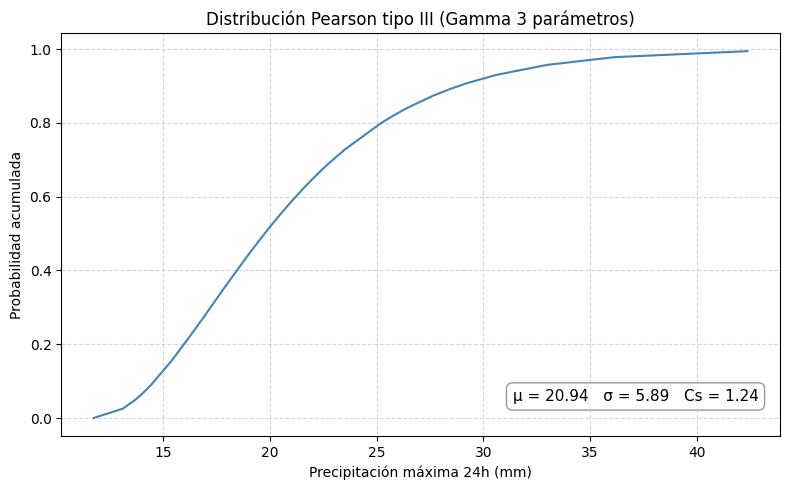

In [30]:
def func_gamma3(y):
    """Función de densidad de la distribución Pearson III."""
    return (y ** (gamma_gamma3 - 1) * math.exp(-y)) / math.gamma(gamma_gamma3)


try:
    # Parámetros por método de los momentos
    mu_gamma3    = tabla_bondad["Xm (mm)"].mean()
    var_gamma3   = tabla_bondad["Xm (mm)"].var()
    n_gamma3     = len(tabla_bondad)

    # Momento central de orden 3 y coeficiente de asimetría
    M3_gamma3 = sum(
        (xg - mu_gamma3) ** 3 / n_gamma3
        for xg in tabla_bondad["Xm (mm)"]
    )
    C_gamma3 = (n_gamma3**2 * M3_gamma3) / (
        (n_gamma3 - 1) * (n_gamma3 - 2) * math.sqrt(var_gamma3) ** 3
    )

    # Parámetros de la distribución
    Xo_gamma3    = mu_gamma3 - 2 * math.sqrt(var_gamma3) / C_gamma3
    beta_gamma3  = C_gamma3 * math.sqrt(var_gamma3) / 2
    gamma_gamma3 = 4 / C_gamma3 ** 2

    # Probabilidad acumulada por integración numérica
    x_gamma3 = tabla_bondad["Xm (mm)"].tolist()
    y_gamma3 = [(xg - Xo_gamma3) / beta_gamma3 for xg in x_gamma3]

    fp_gamma3 = [
        round(quad(func_gamma3, 0, yg)[0], 4)
        for yg in y_gamma3
    ]

    # Agrega columnas a la tabla de bondad
    tabla_bondad["Pearson III"]       = fp_gamma3
    tabla_bondad["Delta Pearson III"] = abs(
        tabla_bondad["Pearson III"] - tabla_bondad["Fo (Xm)"]
    )

    # Gráfico
    plt.figure(figsize=(8, 5))
    plt.plot(x_gamma3, fp_gamma3, color="steelblue", linewidth=1.5)
    plt.title("Distribución Pearson tipo III (Gamma 3 parámetros)")
    plt.xlabel("Precipitación máxima 24h (mm)")
    plt.ylabel("Probabilidad acumulada")
    plt.text(
        0.97, 0.08,
        f"μ = {mu_gamma3:.2f}   σ = {math.sqrt(var_gamma3):.2f}   Cs = {C_gamma3:.2f}",
        fontsize=11,
        ha="right", va="bottom",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
    )
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(ubi_carpeta, "Pearson_III.pdf"), dpi=200)
    plt.savefig(os.path.join(ubi_carpeta, "Pearson_III.png"), dpi=200)
    plt.show()

except Exception as e:
    print(f"Error en distribución Pearson III: {e}")
    tabla_bondad["Pearson III"]       = 0
    tabla_bondad["Delta Pearson III"] = 0

### Distribución Log-Pearson tipo III

Se ajusta la distribución Log-Pearson tipo III a la serie de precipitaciones máximas y se calcula el estadístico Delta para la
prueba de Kolmogorov-Smirnov.

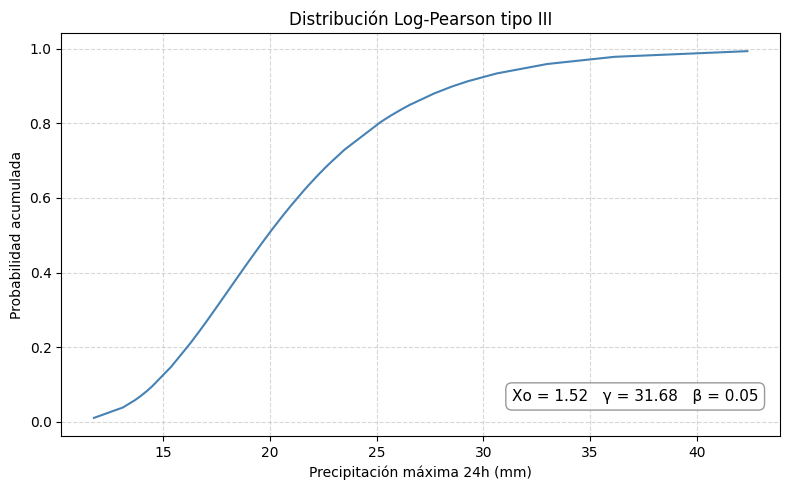

In [31]:
try:
    # Parámetros por método de los momentos sobre la serie logarítmica
    mu_lp3  = tabla_bondad["Ln (Xm)"].mean()
    var_lp3 = tabla_bondad["Ln (Xm)"].var()
    n_lp3   = len(tabla_bondad)

    # Momento central de orden 3 — consistente con Pearson III
    M3_lp3 = sum(
        (x - mu_lp3) ** 3 / n_lp3
        for x in tabla_bondad["Ln (Xm)"]
    )
    CS_lp3 = (n_lp3 ** 2 * M3_lp3) / (
        (n_lp3 - 1) * (n_lp3 - 2) * math.sqrt(var_lp3) ** 3
    )

    # Parámetros de la distribución
    xo_lp3    = mu_lp3 - 2 * math.sqrt(var_lp3) / CS_lp3
    beta_lp3  = CS_lp3 * math.sqrt(var_lp3) / 2
    gamma_lp3 = 4 / CS_lp3 ** 2

    # Tabla de parámetros
    tabla_params_lp3 = pd.DataFrame({
        "Valor": [xo_lp3, gamma_lp3, beta_lp3]
    }, index=pd.Index(["Xo", "γ (gamma)", "β (beta)"], name="Parámetro"))

    # Probabilidad acumulada usando scipy (evita overflow en integración manual)
    x_lp3 = tabla_bondad["Ln (Xm)"].tolist()
    y_lp3 = [(x - xo_lp3) / beta_lp3 for x in x_lp3]

    # Si beta es negativo (CS negativo) se usa el complemento de la CDF
    if beta_lp3 < 0:
        fp_lp3 = [
            round(1 - sp.gamma.cdf(y, a=gamma_lp3), 4) if y > 0 else 1.0
            for y in y_lp3
        ]
    else:
        fp_lp3 = [
            round(sp.gamma.cdf(y, a=gamma_lp3), 4) if y > 0 else 0.0
            for y in y_lp3
        ]

    # Agrega columnas a la tabla de bondad
    tabla_bondad["Log Pearson Tipo III"]       = fp_lp3
    tabla_bondad["Delta Log Pearson Tipo III"] = abs(
        tabla_bondad["Log Pearson Tipo III"] - tabla_bondad["Fo (Xm)"]
    )

    # Gráfico
    plt.figure(figsize=(8, 5))
    plt.plot(tabla_bondad["Xm (mm)"].tolist(), fp_lp3, color="steelblue", linewidth=1.5)
    plt.title("Distribución Log-Pearson tipo III")
    plt.xlabel("Precipitación máxima 24h (mm)")
    plt.ylabel("Probabilidad acumulada")
    plt.text(
        0.97, 0.08,
        f"Xo = {xo_lp3:.2f}   γ = {gamma_lp3:.2f}   β = {beta_lp3:.2f}",
        fontsize=11,
        ha="right", va="bottom",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
    )
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(ubi_carpeta, "Log_Pearson_Tipo_III.pdf"), dpi=200)
    plt.savefig(os.path.join(ubi_carpeta, "Log_Pearson_Tipo_III.png"), dpi=200)
    plt.show()

except Exception as e:
    print(f"Error en distribución Log-Pearson tipo III: {e}")
    tabla_bondad["Log Pearson Tipo III"]       = 0
    tabla_bondad["Delta Log Pearson Tipo III"] = 0

### Distribución Gumbel

Se ajusta la distribución Gumbel (valor extremo tipo I) a la serie de precipitaciones máximas y se calcula el estadístico Delta para la
prueba de Kolmogorov-Smirnov.

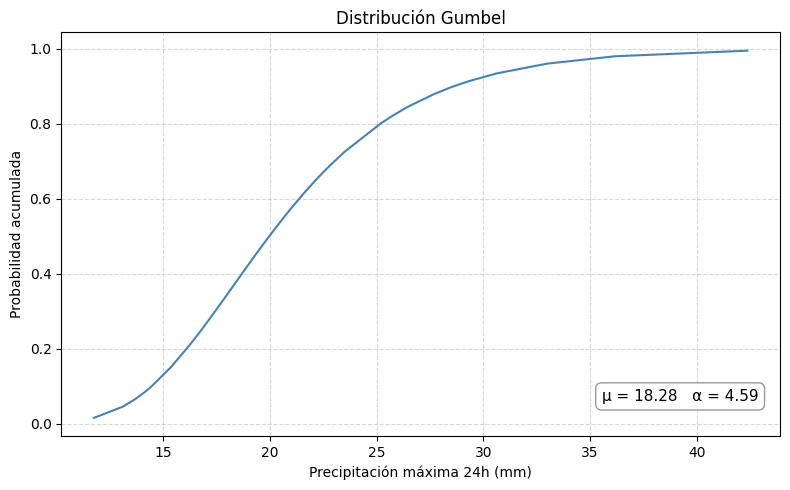

In [32]:
def func_gumbel(y):
    """Función de distribución acumulada de Gumbel."""
    return math.exp(-math.exp(-y))


try:
    # Constante de Euler-Mascheroni
    C_euler = round((1.0 - math.gamma(1 + 1e-8)) * 1e14, 15) * 1e-6

    # Parámetros de la distribución
    media_gumbel = tabla_bondad["Xm (mm)"].mean()
    sigma_gumbel = tabla_bondad["Xm (mm)"].std()
    alpha_gumbel = (math.sqrt(6) / math.pi) * sigma_gumbel
    mu_gumbel    = media_gumbel - C_euler * alpha_gumbel

    # Probabilidad acumulada
    x_gumbel  = tabla_bondad["Xm (mm)"].tolist()
    y_gumbel  = [(x - mu_gumbel) / alpha_gumbel for x in x_gumbel]
    fp_gumbel = [round(func_gumbel(y), 4) for y in y_gumbel]

    # Agrega columnas a la tabla de bondad
    tabla_bondad["Gumbel"]       = fp_gumbel
    tabla_bondad["Delta Gumbel"] = abs(
        tabla_bondad["Gumbel"] - tabla_bondad["Fo (Xm)"]
    )

    # Gráfico
    plt.figure(figsize=(8, 5))
    plt.plot(x_gumbel, fp_gumbel, color="steelblue", linewidth=1.5)
    plt.title("Distribución Gumbel")
    plt.xlabel("Precipitación máxima 24h (mm)")
    plt.ylabel("Probabilidad acumulada")
    plt.text(
        0.97, 0.08,
        f"μ = {mu_gumbel:.2f}   α = {alpha_gumbel:.2f}",
        fontsize=11,
        ha="right", va="bottom",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
    )
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(ubi_carpeta, "Gumbel.pdf"), dpi=200)
    plt.savefig(os.path.join(ubi_carpeta, "Gumbel.png"), dpi=200)
    plt.show()

except Exception as e:
    print(f"Error en distribución Gumbel: {e}")
    tabla_bondad["Gumbel"]       = 0
    tabla_bondad["Delta Gumbel"] = 0

## Resumen de parámetros de las distribuciones ajustadas

Se consolidan los parámetros estimados para cada distribución de probabilidad ajustada a la serie de precipitaciones máximas.

In [33]:
tabla_parametros = pd.DataFrame([
    {
        "Distribución"              : "Normal",
        "Parámetro 1"               : f"μ = {round(mu_n, 4)}",
        "Parámetro 2"               : f"σ = {round(sigma_n, 4)}",
        "Parámetro 3"               : "-"
    },
    {
        "Distribución"              : "Log-Normal 2 parámetros",
        "Parámetro 1"               : f"μy = {round(mu_ln, 4)}",
        "Parámetro 2"               : f"σy = {round(sigma_ln, 4)}",
        "Parámetro 3"               : "-"
    },
    {
        "Distribución"              : "Log-Normal 3 parámetros",
        "Parámetro 1"               : f"μy = {round(mu_ln3, 4)}",
        "Parámetro 2"               : f"σy = {round(sigma_ln3, 4)}",
        "Parámetro 3"               : f"Xo = {round(xo_ln3, 4)}"
    },
    {
        "Distribución"              : "Pearson III (Gamma de 3 parámetros)",
        "Parámetro 1"               : f"Xo = {round(Xo_gamma3, 4)}",
        "Parámetro 2"               : f"γ = {round(gamma_gamma3, 4)}",
        "Parámetro 3"               : f"β = {round(beta_gamma3, 4)}"
    },
    {
        "Distribución"              : "Log-Pearson III",
        "Parámetro 1"               : f"Xo = {round(xo_lp3, 4)}",
        "Parámetro 2"               : f"γ = {round(gamma_lp3, 4)}",
        "Parámetro 3"               : f"β = {round(beta_lp3, 4)}"
    },
    {
        "Distribución"              : "Gumbel",
        "Parámetro 1"               : f"μ = {round(mu_gumbel, 4)}",
        "Parámetro 2"               : f"α = {round(alpha_gumbel, 4)}",
        "Parámetro 3"               : "-"
    },
]).set_index("Distribución")

tabla_parametros

,Parámetro 1,Parámetro 2,Parámetro 3
Distribución,,,
Normal,μ = 20.9362,σ = 5.891,-
Log-Normal 2 parámetros,μy = 3.0062,σy = 0.264,-
Log-Normal 3 parámetros,μy = 2.5577,σy = 0.4054,Xo = 6.9346
Pearson III (Gamma de 3 parámetros),Xo = 11.4319,γ = 2.603,β = 3.6513
Log-Pearson III,Xo = 1.52,γ = 31.6838,β = 0.0469
Gumbel,μ = 18.2849,α = 4.5932,-


## Vista previa de la tabla de bondad de ajuste

Se muestran los primeros 10 registros de la tabla con las probabilidades
acumuladas calculadas para cada distribución ajustada.

In [34]:
tabla_bondad.head(10)

,Xm (mm),Fo (Xm),Normal,Delta Normal,Ln (Xm),Log Normal 2 Parámetros,Delta Log Normal 2 Parámetros,Ln (Xm-Xo),Log Normal 3 Parámetros,Delta Log Normal 3 Parámetros,Pearson III,Delta Pearson III,Log Pearson Tipo III,Delta Log Pearson Tipo III,Gumbel,Delta Gumbel
N°,,,,,,,,,,,,,,,,
1,11.752,0.016949,0.059495,0.042546,2.464023,0.020018,0.003069,1.572238,0.007538,0.009411,0.0004,0.016549,0.0103,0.006649,0.0158,0.001149
2,13.108,0.033898,0.091949,0.058051,2.573223,0.050525,0.016627,1.820252,0.034470,0.000572,0.0255,0.008398,0.0382,0.004302,0.0457,0.011802
3,13.108,0.050847,0.091949,0.041102,2.573223,0.050525,0.000323,1.820252,0.034470,0.016377,0.0255,0.025347,0.0382,0.012647,0.0457,0.005147
4,13.673,0.067797,0.108800,0.041003,2.615423,0.069443,0.001647,1.907825,0.054488,0.013308,0.0487,0.019097,0.0578,0.009997,0.0653,0.002497
5,13.899,0.084746,0.116127,0.031381,2.631817,0.078116,0.006630,1.940814,0.064075,0.020671,0.0599,0.024846,0.0671,0.017646,0.0744,0.010346
6,14.012,0.101695,0.119919,0.018224,2.639914,0.082692,0.019003,1.956909,0.069204,0.032491,0.0659,0.035795,0.0721,0.029595,0.0792,0.022495
7,14.125,0.118644,0.123798,0.005154,2.647946,0.087427,0.031217,1.972749,0.074556,0.044088,0.0721,0.046544,0.0773,0.041344,0.0843,0.034344
8,14.238,0.135593,0.127764,0.007830,2.655914,0.092322,0.043271,1.988342,0.080128,0.055465,0.0786,0.056993,0.0826,0.052993,0.0895,0.046093
9,14.464,0.152542,0.135958,0.016585,2.671663,0.102588,0.049954,2.018817,0.091917,0.060626,0.0922,0.060342,0.0940,0.058542,0.1005,0.052042


## Estadístico de Kolmogorov-Smirnov (Δ máximo por distribución)

Se obtiene el valor máximo del estadístico Delta para cada distribución,
que corresponde al estadístico Dn de la prueba de Kolmogorov-Smirnov.

In [35]:
# Extrae las columnas Delta de la tabla de bondad
columnas_delta = [col for col in tabla_bondad.columns if "Delta" in col]

# Tabla con el Delta máximo (estadístico Dn) por distribución
tabla_deltas = pd.DataFrame({
    "Δ máximo (Dn)": tabla_bondad[columnas_delta].max()
})
tabla_deltas.index.name = "Distribución"

tabla_deltas

,Δ máximo (Dn)
Distribución,
Delta Normal,0.119943
Delta Log Normal 2 Parámetros,0.068139
Delta Log Normal 3 Parámetros,0.060626
Delta Pearson III,0.063964
Delta Log Pearson Tipo III,0.058542
Delta Gumbel,0.056463


## Valores de deltas críticos de la prueba de Kolmogorov-Smirnov

Tabla de valores críticos Δ para distintos niveles de significancia. Se selecciona el nivel α = 0.05 para la evaluación
del ajuste de cada distribución.

In [36]:
# Valores críticos de la prueba K-S (Massey, 1951)
# Niveles de significancia: 0.20, 0.15, 0.10, 0.05, 0.01
ks_n      = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,25,30,35]
ks_020    = [0.900,0.684,0.565,0.493,0.446,0.410,0.381,0.358,0.339,0.322,0.307,0.295,0.284,0.274,0.266,0.258,0.250,0.244,0.237,0.231,0.21,0.19,0.18]
ks_015    = [0.925,0.726,0.597,0.474,0.474,0.436,0.405,0.381,0.360,0.342,0.326,0.313,0.302,0.292,0.283,0.274,0.266,0.259,0.252,0.246,0.22,0.20,0.19]
ks_010    = [0.950,0.776,0.642,0.510,0.510,0.468,0.438,0.411,0.388,0.368,0.352,0.338,0.325,0.314,0.304,0.295,0.286,0.278,0.272,0.264,0.24,0.22,0.21]
ks_005    = [0.975,0.842,0.708,0.624,0.563,0.519,0.486,0.457,0.432,0.409,0.391,0.375,0.361,0.349,0.338,0.328,0.318,0.309,0.301,0.294,0.264,0.242,0.23]
ks_001    = [0.995,0.929,0.829,0.734,0.669,0.617,0.577,0.543,0.514,0.486,0.468,0.450,0.433,0.418,0.404,0.391,0.380,0.370,0.361,0.352,0.32,0.29,0.27]

tabla_significacion = pd.DataFrame({
    "0.20": ks_020,
    "0.15": ks_015,
    "0.10": ks_010,
    "0.05": ks_005,
    "0.01": ks_001
}, index=pd.Index(ks_n, name="n"))

tabla_significacion

,0.20,0.15,0.10,0.05,0.01
n,,,,,
1,0.900,0.925,0.950,0.975,0.995
2,0.684,0.726,0.776,0.842,0.929
3,0.565,0.597,0.642,0.708,0.829
4,0.493,0.474,0.510,0.624,0.734
5,0.446,0.474,0.510,0.563,0.669
6,0.410,0.436,0.468,0.519,0.617
7,0.381,0.405,0.438,0.486,0.577
8,0.358,0.381,0.411,0.457,0.543
9,0.339,0.360,0.388,0.432,0.514


Se definen las funciones para obtener el valor crítico Δ de la prueba de Kolmogorov-Smirnov según el tamaño de muestra y nivel de significancia.
Para n ≤ 35 se interpola en la tabla; para n > 35 se aplica la fórmula asintótica correspondiente.

In [37]:
# Fórmulas asintóticas por nivel de significación
FORMULAS_ASINTOTICAS = {
    0.20: 1.07,
    0.15: 1.14,
    0.10: 1.22,
    0.05: 1.36,
    0.01: 1.63
}

def interpolar_delta(n, significancia):
    """
    Interpola el delta crítico en la tabla para n ≤ 35.

    Parámetros
    ----------
    n            : int   — tamaño de muestra
    significancia: float — nivel de significancia (0.20, 0.15, 0.10, 0.05, 0.01)

    Retorna
    -------
    float — valor crítico interpolado
    """
    columna = tabla_significacion[str(significancia)]
    return np.interp(n, list(tabla_significacion.index), columna)


def delta_asintotico(n, significancia):
    """
    Calcula el delta crítico por fórmula asintótica para n > 35.

    Parámetros
    ----------
    n            : int   — tamaño de muestra
    significancia: float — nivel de significancia

    Retorna
    -------
    float — valor crítico asintótico
    """
    if significancia not in FORMULAS_ASINTOTICAS:
        raise ValueError(f"Significancia {significancia} no válida. Use: {list(FORMULAS_ASINTOTICAS.keys())}")
    return FORMULAS_ASINTOTICAS[significancia] / math.sqrt(n)


def delta_critico(n, significancia):
    """
    Obtiene el delta crítico de K-S según el tamaño de muestra.
    - n exacto en tabla → valor directo
    - n ≤ 35 no exacto  → interpolación lineal
    - n > 35            → fórmula asintótica

    Parámetros
    ----------
    n            : int   — tamaño de muestra
    significancia: float — nivel de significancia

    Retorna
    -------
    float — valor crítico Δ
    """
    sig_str = str(significancia)
    if n in tabla_significacion.index:
        return tabla_significacion.loc[n, sig_str]
    elif n <= 35:
        return interpolar_delta(n, significancia)
    else:
        return delta_asintotico(n, significancia)

Ingresa el nivel de significación con el que deseas evaluar el ajuste
de las distribuciones. Valores disponibles: 0.20, 0.15, 0.10, 0.05, 0.01

In [38]:
# ---------------------------------------------------------------
# MODIFICA ESTE VALOR según el nivel de significación deseado
# ---------------------------------------------------------------
nivel_significacion = 0.05

# Calcula el delta crítico para el tamaño de muestra actual
N_muestra = tabla_bondad.shape[0]
D_critico = delta_critico(N_muestra, nivel_significacion)

print("Parámetros de la prueba K-S")
print("─" * 32)
print(f"N° de datos            : {N_muestra}")
print(f"Nivel de significación : {nivel_significacion}")
print(f"Delta crítico (Dc)     : {D_critico:.4f}")

Parámetros de la prueba K-S
────────────────────────────────
N° de datos            : 58
Nivel de significación : 0.05
Delta crítico (Dc)     : 0.1786


## Resumen de la prueba de Kolmogorov-Smirnov

Se evalúa el ajuste de cada distribución comparando el delta teórico
calculado con el delta crítico tabulado para el nivel de significación
seleccionado.

In [39]:
# Construye la tabla resumen de la prueba K-S
tabla_resumen_ks = pd.DataFrame({
    "Distribución de probabilidad" : list(tabla_deltas.index),
    "Prueba estadística"           : "Smirnov-Kolmogorov",
    "Nivel de significación (α)"   : f"{int(nivel_significacion * 100)}%",
    "Delta crítico (Δo)"           : D_critico,
    "Delta teórico (Δ)"            : list(tabla_deltas["Δ máximo (Dn)"]),
})

# Evalúa el resultado por distribución
tabla_resumen_ks["Resultado"] = tabla_resumen_ks["Delta teórico (Δ)"].apply(
    lambda d: "Se ajusta" if 0 < d <= D_critico else "No se ajusta"
)

tabla_resumen_ks

,Distribución de probabilidad,Prueba estadística,Nivel de significación (α),Delta crítico (Δo),Delta teórico (Δ),Resultado
0,Delta Normal,Smirnov-Kolmogorov,5%,0.178577,0.119943,Se ajusta
1,Delta Log Normal 2 Parámetros,Smirnov-Kolmogorov,5%,0.178577,0.068139,Se ajusta
2,Delta Log Normal 3 Parámetros,Smirnov-Kolmogorov,5%,0.178577,0.060626,Se ajusta
3,Delta Pearson III,Smirnov-Kolmogorov,5%,0.178577,0.063964,Se ajusta
4,Delta Log Pearson Tipo III,Smirnov-Kolmogorov,5%,0.178577,0.058542,Se ajusta
5,Delta Gumbel,Smirnov-Kolmogorov,5%,0.178577,0.056463,Se ajusta


Distribución seleccionada:

Se selecciona automáticamente la distribución con el menor delta teórico
entre las que aprobaron la prueba de Kolmogorov-Smirnov.

In [40]:
# Filtra solo las distribuciones que se ajustan
distribuciones_aceptadas = tabla_resumen_ks[
    tabla_resumen_ks["Resultado"] == "Se ajusta"
]

# Selecciona la de menor delta teórico
delta_min        = distribuciones_aceptadas["Delta teórico (Δ)"].min()
distribucion_elegida = distribuciones_aceptadas.loc[
    distribuciones_aceptadas["Delta teórico (Δ)"] == delta_min,
    "Distribución de probabilidad"
].values[0]

print("Distribución seleccionada")
print("─" * 42)
print(f"Distribución : {distribucion_elegida}")
print(f"Delta teórico: {delta_min:.4f}")
print(f"Delta crítico: {D_critico:.4f}")

Distribución seleccionada
──────────────────────────────────────────
Distribución : Delta Gumbel
Delta teórico: 0.0565
Delta crítico: 0.1786


## Periodos de retorno

Se definen los periodos de retorno para el cálculo de precipitaciones
de diseño y se calcula la probabilidad de excedencia correspondiente.

In [41]:
# Periodos de retorno (años)
periodos_retorno = [5, 10, 20, 35, 50, 70, 100, 140, 175, 500]

# Construye la tabla con probabilidad de excedencia P = 1/T
dist_frecuencias = pd.DataFrame({
    "T (años)": periodos_retorno,
    "P"        : [round(1 / T, 6) for T in periodos_retorno]
})

dist_frecuencias

,T (años),P
0,5,0.200000
1,10,0.100000
2,20,0.050000
3,35,0.028571
4,50,0.020000
5,70,0.014286
6,100,0.010000
7,140,0.007143
8,175,0.005714
9,500,0.002000


Preparación para el cálculo de precipitaciones de diseño:

Se define la función de bisección para invertir la CDF de cada distribución
y se calculan las columnas auxiliares necesarias para la distribución
Log-Normal 3 parámetros.

In [42]:
def bisec_x(f, a, b, integral_value):
    """
    Encuentra el valor x tal que la integral de f desde a hasta x
    sea igual a integral_value, usando el método de bisección.

    Parámetros
    ----------
    f             : callable — función de densidad
    a             : float    — límite inferior de integración
    b             : float    — límite superior de búsqueda
    integral_value: float    — valor objetivo de la integral acumulada

    Retorna
    -------
    float — valor x que satisface la condición
    """
    return scipy.optimize.bisect(
        lambda x: scipy.integrate.quad(f, a, x)[0] - integral_value,
        a, b
    )


# Estadísticos para el parámetro Xo de Log-Normal 3P
xe_min     = serie_frecuencia["Pp max. 24 horas (mm)"].min()
xe_max     = serie_frecuencia["Pp max. 24 horas (mm)"].max()
xe_mediana = serie_frecuencia["Pp max. 24 horas (mm)"].median()

xo_lognormaln3 = (
    (xe_min * xe_max - xe_mediana**2) /
    (xe_min + xe_max - 2 * xe_mediana)
)

# Columna Ln(Ppm - Ppo) para Log-Normal 3P
serie_frecuencia["Ln (Ppm-Ppo)"] = serie_frecuencia["Pp max. 24 horas (mm)"].apply(
    lambda x: math.log(x - xo_lognormaln3)
)

serie_frecuencia.head()

,Año,Pp max. 24 horas (mm),Log10 Pp max. 24 horas (mm),Ln (Ppm-Ppo)
0,1967,14.464,1.1603,2.018817
1,1968,11.752,1.0701,1.572238
2,1969,16.724,1.2233,2.281302
3,1970,20.114,1.3035,2.578656
4,1971,13.108,1.1175,1.820252


# ESTIMACIÓN DE PRECIPITACIONES DE DISEÑO

## Funciones de densidad para el cálculo de precipitaciones de diseño

Se definen las funciones de densidad de probabilidad para cada distribución
ajustada, usando los parámetros calculados en las secciones anteriores.

In [43]:
def D_Normal(x):
    """FDA de la distribución Normal."""
    return (1 / (sigma_n * math.sqrt(2 * math.pi))) * \
        math.exp(-0.5 * ((x - mu_n) / sigma_n) ** 2)


def D_Log_Normal_2(x):
    """FDA de la distribución Log-Normal 2 parámetros."""
    return (1 / (sigma_ln * math.sqrt(2 * math.pi))) * \
        math.exp(-0.5 * ((x - mu_ln) / sigma_ln) ** 2)


def D_Log_Normal_3(x):
    """FDA de la distribución Log-Normal 3 parámetros."""
    return (1 / (sigma_ln3 * math.sqrt(2 * math.pi))) * \
        math.exp(-0.5 * ((x - mu_ln3) / sigma_ln3) ** 2)


def D_Gamma_3(y):
    """FDA de la distribución Gamma 3 parámetros (Pearson III)."""
    return (y ** (gamma_gamma3 - 1) * math.exp(-y)) / math.gamma(gamma_gamma3)


def D_Log_Pearson_3(y):
    """FDA de la distribución Log-Pearson tipo III usando scipy."""
    if y <= 0:
        return 0.0
    return sp.gamma.pdf(y, a=gamma_lp3)


def D_Gumbel(y):
    """FDA de la distribución Gumbel."""
    return math.exp(-math.exp(-y))

## Función para determinar los límites de integración

Se define la función que calcula los límites inferior y superior de
integración para cada distribución, necesarios para el cálculo de
precipitaciones de diseño por el método de bisección.

In [44]:
def limites_distribuciones(nombre_dist, funcion_dist, l_i, l_s):
    """
    Calcula los límites de integración usando scipy para mayor robustez.
    """
    dists_no_ajustan = tabla_resumen_ks[
        tabla_resumen_ks["Resultado"] == "No se ajusta"
    ]["Distribución de probabilidad"].tolist()

    if nombre_dist in dists_no_ajustan:
        return 0, 0

    try:
        if nombre_dist == "Normal":
            dist = sp.norm(mu_n, sigma_n)
            return int(dist.ppf(0.0001)), int(dist.ppf(0.9999)) + 1

        elif nombre_dist == "Log-Normal 2 parámetros":
            dist = sp.norm(mu_ln, sigma_ln)
            return int(dist.ppf(0.0001)), int(dist.ppf(0.9999)) + 1

        elif nombre_dist == "Log-Normal 3 parámetros":
            dist = sp.norm(mu_ln3, sigma_ln3)
            return int(dist.ppf(0.0001)), int(dist.ppf(0.9999)) + 1

        elif nombre_dist == "Pearson tipo III":
            dist  = sp.gamma(a=gamma_gamma3)
            y_max = dist.ppf(0.9999)
            y_min = dist.ppf(0.0001)
            return int(y_min), int(y_max) + 1

        elif nombre_dist == "Log-Pearson tipo III":
            # rango basado en ppf de sp.gamma
            dist  = sp.gamma(a=gamma_lp3)
            y_max = dist.ppf(0.9999)
            y_min = dist.ppf(0.0001)
            return int(y_min), int(y_max) + 1

        elif nombre_dist == "Gumbel":
            # Límites en escala original de precipitación
            # F(x) = exp(-exp(-(x-mu)/alpha))
            # x = mu - alpha * ln(-ln(p))
            x_min = mu_gumbel - alpha_gumbel * math.log(-math.log(0.9999))
            x_max = mu_gumbel - alpha_gumbel * math.log(-math.log(0.0001))
            return int(x_min) - 1, int(x_max) + 1

    except Exception as e:
        print(f"Error en límites {nombre_dist}: {e}")
        return 0, 0

## Cálculo de límites de integración por distribución

Se determinan los límites inferior y superior de integración para
cada distribución ajustada.

In [45]:
# Límite superior dinámico basado en los datos reales
pp_max_serie = serie_frecuencia["Pp max. 24 horas (mm)"].max()
ls_dinamico  = int(pp_max_serie * 5)  # margen amplio

config_distribuciones = [
    ("Normal",                  D_Normal,        -ls_dinamico, ls_dinamico),
    ("Log-Normal 2 parámetros", D_Log_Normal_2,  -100,         100),
    ("Log-Normal 3 parámetros", D_Log_Normal_3,  -100,         100),
    ("Pearson tipo III",        D_Gamma_3,        0,            ls_dinamico),
    ("Log-Pearson tipo III",    D_Log_Pearson_3,  0,            100),
    ("Gumbel",                  D_Gumbel,         1,            ls_dinamico),
]

# Calcula los límites para cada distribución
limites = {}
for nombre, funcion, l_i, l_s in config_distribuciones:
    try:
        li, ls = limites_distribuciones(nombre, funcion, l_i, l_s)
    except Exception:
        li, ls = limites_distribuciones(nombre, funcion, 0, l_s)
    limites[nombre] = (li, ls)
    print(f"{nombre:35s} → [{li:5d}, {ls:5d}]")

Normal                              → [    0,    43]
Log-Normal 2 parámetros             → [    2,     4]
Log-Normal 3 parámetros             → [    1,     5]
Pearson tipo III                    → [    0,    14]
Log-Pearson tipo III                → [   14,    57]
Gumbel                              → [   59,     9]


In [46]:
# Obtiene el rango de años automáticamente desde la serie histórica
año_min = int(serie_frecuencia["Año"].min())
año_max = int(serie_frecuencia["Año"].max())

lista_años = list(range(año_min, año_max + 1))

print(f"Rango de años detectado: {año_min} — {año_max}")

Rango de años detectado: 1967 — 2025


## Función inversa de distribuciones

Se define la función que calcula la precipitación de diseño para una
probabilidad de no excedencia dada.

In [47]:
def distribuciones_inv(distribucion, integral_value):
    """
    Calcula la precipitación de diseño para una probabilidad
    de no excedencia dada, invirtiendo la CDF de la distribución.

    Parámetros
    ----------
    distribucion   : str   — nombre de la distribución
    integral_value : float — probabilidad de no excedencia (1 - 1/T)

    Retorna
    -------
    float — precipitación de diseño en mm (0 si falla el cálculo)
    """
    li, ls = limites.get(distribucion, (0, 0))

    try:
        if distribucion == "Normal":
            return bisec_x(D_Normal, li, ls, integral_value)

        elif distribucion == "Log-Normal 2 parámetros":
            res = bisec_x(D_Log_Normal_2, li, ls, integral_value)
            return math.exp(res)

        elif distribucion == "Log-Normal 3 parámetros":
            res = bisec_x(D_Log_Normal_3, li, ls, integral_value)
            return math.exp(res) + xo_lognormaln3

        elif distribucion == "Pearson tipo III":
            y = sp.gamma.ppf(integral_value, a=gamma_gamma3)
            return Xo_gamma3 + y * beta_gamma3

        elif distribucion == "Log-Pearson tipo III":
            if beta_lp3 < 0:
                # CS negativo: invierte la CDF
                y = sp.gamma.ppf(1 - integral_value, a=gamma_lp3)
            else:
                y = sp.gamma.ppf(integral_value, a=gamma_lp3)
            return math.exp(xo_lp3 + y * beta_lp3)

        elif distribucion == "Gumbel":
            res = scipy.optimize.fsolve(
                lambda x: D_Gumbel(x) - integral_value, 1
            )[0]
            return mu_gumbel + res * alpha_gumbel

        else:
            return 0

    except Exception:
        return 0

## Precipitaciones de diseño por distribución y periodo de retorno

Se calculan las precipitaciones máximas de diseño para cada distribución
ajustada y periodo de retorno definido anteriormente.

In [48]:
# Calcula precipitaciones de diseño para cada distribución y periodo de retorno
for dist in config_distribuciones:
    nombre = dist[0]
    dist_frecuencias[nombre] = [
        distribuciones_inv(nombre, 1 - p)
        for p in dist_frecuencias["P"]
    ]

dist_frecuencias

C:\Users\Joseph\AppData\Local\Temp\ipykernel_29952\2224336614.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return math.exp(-math.exp(-y))


,T (años),P,Normal,Log-Normal 2 parámetros,Log-Normal 3 parámetros,Pearson tipo III,Log-Pearson tipo III,Gumbel
0,5,0.200000,25.898120,25.240313,25.089909,25.220831,25.093460,25.174393
1,10,0.100000,28.492110,28.350201,28.636021,28.830166,28.587734,28.621225
2,20,0.050000,30.636787,31.206557,32.082420,32.222800,31.990535,31.927509
3,35,0.028571,32.159239,33.404245,34.852167,34.858721,34.735852,34.548868
4,50,0.020000,33.057896,34.771140,36.624957,36.502561,36.499089,36.207155
5,70,0.014286,33.864447,36.043050,38.308208,38.032040,38.177814,37.765847
6,100,0.010000,34.682876,37.377564,40.108450,39.634068,39.977845,39.414148
7,140,0.007143,35.425975,38.627053,41.825002,41.129069,41.697989,40.966135
8,175,0.005714,35.906038,39.452773,42.975491,42.113167,42.852416,41.994690
9,500,0.002000,38.075686,43.336929,48.551734,46.671683,48.443768,46.825018


## Precipitaciones de diseño con la distribución seleccionada

Se construye la tabla de precipitaciones de diseño para cada periodo
de retorno usando la distribución seleccionada por la prueba K-S.

In [49]:
# Limpieza del nombre de la distribución seleccionada
distribucion_elegida = distribucion_elegida.replace("Delta ", "")

# Mapeo por si el nombre no coincide exactamente con las columnas de dist_frecuencias
mapeo_nombres = {
    "Log Pearson Tipo III"   : "Log-Pearson tipo III",
    "Log Normal 2 Parámetros": "Log-Normal 2 parámetros",
    "Log Normal 3 Parámetros": "Log-Normal 3 parámetros",
    "Gamma 3 Parámetros"     : "Pearson tipo III",
    "Pearson III"            : "Pearson tipo III",
    "Pearson tipo III"       : "Pearson tipo III",
    "Gumbel"                 : "Gumbel",
    "Normal"                 : "Normal",
}
distribucion_elegida = mapeo_nombres.get(distribucion_elegida, distribucion_elegida)

# Tabla de precipitaciones de diseño con la distribución seleccionada
prob_excedencia = dist_frecuencias[["T (años)", "P", distribucion_elegida]].copy()
prob_excedencia = prob_excedencia.sort_values("T (años)", ascending=False).reset_index(drop=True)
prob_excedencia["Prob. de excedencia"] = 1 - prob_excedencia["P"]

print(f"Distribución seleccionada: {distribucion_elegida}")
print("─" * 40)
prob_excedencia

Distribución seleccionada: Gumbel
────────────────────────────────────────


,T (años),P,Gumbel,Prob. de excedencia
0,500,0.002000,46.825018,0.998000
1,175,0.005714,41.994690,0.994286
2,140,0.007143,40.966135,0.992857
3,100,0.010000,39.414148,0.990000
4,70,0.014286,37.765847,0.985714
5,50,0.020000,36.207155,0.980000
6,35,0.028571,34.548868,0.971429
7,20,0.050000,31.927509,0.950000
8,10,0.100000,28.621225,0.900000
9,5,0.200000,25.174393,0.800000


## Verificación de precipitaciones de diseño

Se verifican los valores calculados para cada distribución y periodo de
retorno, filtrando aquellos con precipitación igual a cero antes de
continuar con el cálculo de las curvas IDF.

In [50]:
# Verifica los valores de todas las distribuciones
print("Verificación de precipitaciones de diseño (mm)")
print("─" * 65)

distribuciones_col = [d[0] for d in config_distribuciones]
for dist in distribuciones_col:
    if dist in dist_frecuencias.columns:
        valores = dist_frecuencias[dist]
        n_ceros = (valores == 0).sum()
        estado  = "⚠ con ceros" if n_ceros > 0 else "OK"
        print(f"  {dist:<35s} {estado}  ({n_ceros} valores en cero)")

print()

# Filtra periodos válidos para la distribución seleccionada
mask_validos = dist_frecuencias[distribucion_elegida] > 0
n_invalidos  = (~mask_validos).sum()

periodos  = list(dist_frecuencias.loc[mask_validos, "T (años)"])
pp_diseño = list(dist_frecuencias.loc[mask_validos, distribucion_elegida])

print(f"Distribución seleccionada : {distribucion_elegida}")
print(f"Periodos válidos          : {len(periodos)} de {len(dist_frecuencias)}")

if n_invalidos > 0:
    T_invalidos = list(dist_frecuencias.loc[~mask_validos, "T (años)"])
    print(f"Periodos excluidos        : {T_invalidos}")

print()
print("Periodos de retorno para curvas IDF:")
print("─" * 40)
for T, pp in zip(periodos, pp_diseño):
    print(f"  T = {T:>4.0f} años   →   Pp = {pp:.3f} mm")

Verificación de precipitaciones de diseño (mm)
─────────────────────────────────────────────────────────────────
  Normal                              OK  (0 valores en cero)
  Log-Normal 2 parámetros             OK  (0 valores en cero)
  Log-Normal 3 parámetros             OK  (0 valores en cero)
  Pearson tipo III                    OK  (0 valores en cero)
  Log-Pearson tipo III                OK  (0 valores en cero)
  Gumbel                              OK  (0 valores en cero)

Distribución seleccionada : Gumbel
Periodos válidos          : 10 de 10

Periodos de retorno para curvas IDF:
────────────────────────────────────────
  T =    5 años   →   Pp = 25.174 mm
  T =   10 años   →   Pp = 28.621 mm
  T =   20 años   →   Pp = 31.928 mm
  T =   35 años   →   Pp = 34.549 mm
  T =   50 años   →   Pp = 36.207 mm
  T =   70 años   →   Pp = 37.766 mm
  T =  100 años   →   Pp = 39.414 mm
  T =  140 años   →   Pp = 40.966 mm
  T =  175 años   →   Pp = 41.995 mm
  T =  500 años   →   Pp = 46.

# CURVAS INTENSIDAD-DURACIÓN-FRECUENCIA (IDF)

## Método de Dick y Peschke

Se calculan las intensidades de diseño para diferentes duraciones y
periodos de retorno mediante el método de Dick y Peschke, que relaciona
la precipitación máxima en 24 horas con la de cualquier duración mediante:

**P(t) = P(24h) · (t/1440)^0.25**

donde t es la duración en minutos. La intensidad se obtiene como:

**I(mm/h) = P(t) / t · 60**

In [51]:
# Duraciones de análisis (minutos)
duraciones = [5, 10, 15, 20, 30, 60, 120, 180, 240, 300, 360, 480, 720, 1440]

# Duraciones para el gráfico (hasta 60 minutos)
duraciones_grafico = [d for d in duraciones if d <= 60]

# Periodos y precipitaciones válidas (ya filtradas en la celda anterior)
# periodos y pp_diseño vienen definidos de la verificación previa

# Tabla de precipitaciones por duración (mm)
precipitaciones_mm = pd.DataFrame(index=duraciones)
precipitaciones_mm.index.name = "Duración (min)"

for T, pp24 in zip(periodos, pp_diseño):
    precipitaciones_mm[f"T={int(T)} años"] = [
        round(pp24 * ((t / 1440) ** 0.25), 4)
        for t in duraciones
    ]

print("Precipitaciones de diseño por duración (mm)")
print(f"Distribución: {distribucion_elegida}")
print(f"Periodos de retorno: {[int(T) for T in periodos]} años")
print("─" * 70)
precipitaciones_mm

Precipitaciones de diseño por duración (mm)
Distribución: Gumbel
Periodos de retorno: [5, 10, 20, 35, 50, 70, 100, 140, 175, 500] años
──────────────────────────────────────────────────────────────────────


,T=5 años,T=10 años,T=20 años,T=35 años,T=50 años,T=70 años,T=100 años,T=140 años,T=175 años,T=500 años
Duración (min),,,,,,,,,,
5,6.1110,6.9477,7.7503,8.3866,8.7891,9.1675,9.5676,9.9444,10.1940,11.3666
10,7.2672,8.2622,9.2167,9.9734,10.4521,10.9021,11.3779,11.8259,12.1228,13.5172
15,8.0425,9.1437,10.1999,11.0374,11.5672,12.0651,12.5917,13.0875,13.4161,14.9593
20,8.6422,9.8255,10.9605,11.8604,12.4297,12.9648,13.5307,14.0634,14.4165,16.0748
30,9.5642,10.8737,12.1298,13.1257,13.7557,14.3479,14.9741,15.5638,15.9545,17.7897
60,11.3738,12.9311,14.4249,15.6092,16.3584,17.0626,17.8074,18.5085,18.9732,21.1556
120,13.5258,15.3778,17.1542,18.5626,19.4536,20.2910,21.1766,22.0105,22.5631,25.1584
180,14.9688,17.0183,18.9842,20.5429,21.5289,22.4557,23.4358,24.3586,24.9702,27.8423
240,16.0850,18.2873,20.3999,22.0748,23.1343,24.1302,25.1834,26.1750,26.8322,29.9185


In [52]:
# Tabla de intensidades (mm/h)
intensidades_mm = pd.DataFrame(index=duraciones)
intensidades_mm.index.name = "Duración (min)"

for col in precipitaciones_mm.columns:
    intensidades_mm[col] = [
        round((p / t) * 60, 4)
        for p, t in zip(precipitaciones_mm[col], duraciones)
    ]

print("Intensidades de diseño (mm/h)")
print("─" * 30)
intensidades_mm

Intensidades de diseño (mm/h)
──────────────────────────────


,T=5 años,T=10 años,T=20 años,T=35 años,T=50 años,T=70 años,T=100 años,T=140 años,T=175 años,T=500 años
Duración (min),,,,,,,,,,
5,73.3320,83.3724,93.0036,100.6392,105.4692,110.0100,114.8112,119.3328,122.3280,136.3992
10,43.6032,49.5732,55.3002,59.8404,62.7126,65.4126,68.2674,70.9554,72.7368,81.1032
15,32.1700,36.5748,40.7996,44.1496,46.2688,48.2604,50.3668,52.3500,53.6644,59.8372
20,25.9266,29.4765,32.8815,35.5812,37.2891,38.8944,40.5921,42.1902,43.2495,48.2244
30,19.1284,21.7474,24.2596,26.2514,27.5114,28.6958,29.9482,31.1276,31.9090,35.5794
60,11.3738,12.9311,14.4249,15.6092,16.3584,17.0626,17.8074,18.5085,18.9732,21.1556
120,6.7629,7.6889,8.5771,9.2813,9.7268,10.1455,10.5883,11.0053,11.2815,12.5792
180,4.9896,5.6728,6.3281,6.8476,7.1763,7.4852,7.8119,8.1195,8.3234,9.2808
240,4.0213,4.5718,5.1000,5.5187,5.7836,6.0325,6.2958,6.5438,6.7081,7.4796


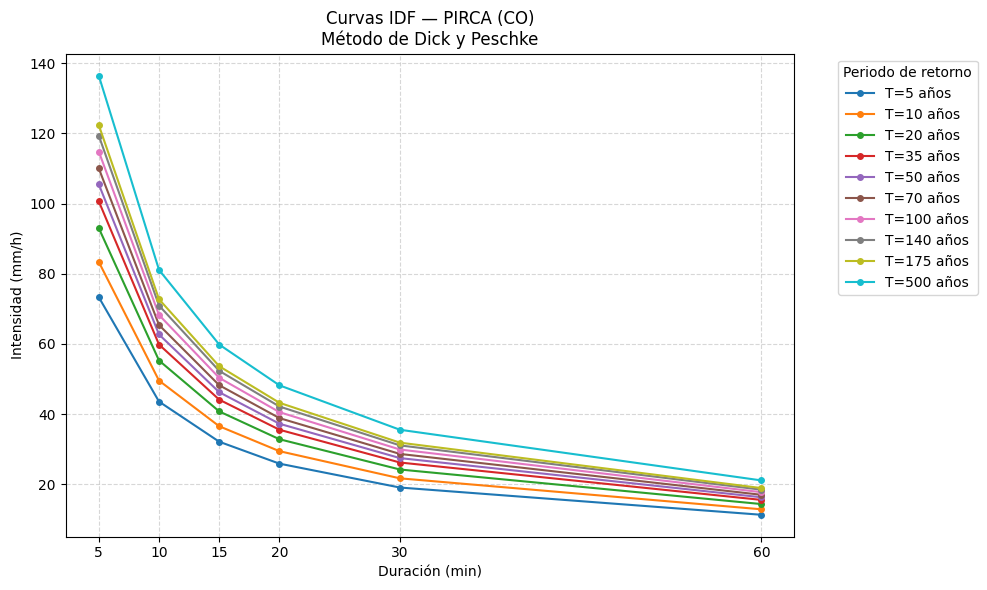

In [53]:
# Gráfico de curvas IDF (hasta 60 minutos)
intensidades_grafico = intensidades_mm.loc[duraciones_grafico]

# Filtra columnas con algún valor cero o negativo
cols_validas = [
    col for col in intensidades_grafico.columns
    if (intensidades_grafico[col] > 0).all()
]

plt.figure(figsize=(10, 6))

for col in cols_validas:
    plt.plot(duraciones_grafico, intensidades_grafico[col], marker="o",
             markersize=4, linewidth=1.5, label=col)

plt.title(f"Curvas IDF — {estacion_e} ({categoria_e})\nMétodo de Dick y Peschke")
plt.xlabel("Duración (min)")
plt.ylabel("Intensidad (mm/h)")
plt.xticks(duraciones_grafico)
plt.legend(title="Periodo de retorno", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(ubi_carpeta, "Curvas_IDF.pdf"), dpi=200)
plt.savefig(os.path.join(ubi_carpeta, "Curvas_IDF.png"), dpi=200)
plt.show()

## Ecuación de ajuste de las curvas IDF

Se determina la ecuación de ajuste de la forma I = K·Tr^m / t^n
mediante regresión lineal múltiple aplicada a la transformación
logarítmica: Log(I) = Log(K) + m·Log(Tr) - n·Log(t)

In [54]:
# Prepara los datos para la regresión lineal múltiple
# Log(I) = a0 + a1·Log(T) + a2·Log(t)
# Solo usa columnas con valores válidos (> 0)
registros = []
for col in cols_validas:
    T = float(col.replace("T=", "").replace(" años", ""))
    for t, I in zip(duraciones, intensidades_mm[col]):
        if I > 0:
            registros.append({
                "Log(I)" : math.log10(I),
                "Log(T)" : math.log10(T),
                "Log(t)" : math.log10(t)
            })

df_regresion = pd.DataFrame(registros)

# Variables de la regresión
Y  = df_regresion["Log(I)"].values
X1 = df_regresion["Log(T)"].values
X2 = df_regresion["Log(t)"].values

# Matriz de diseño: [1, Log(T), Log(t)]
X  = np.column_stack([np.ones(len(Y)), X1, X2])

# Regresión por mínimos cuadrados
coef, residuos, _, _ = np.linalg.lstsq(X, Y, rcond=None)
a0, a1, a2 = coef

# Parámetros de la ecuación IDF
log_K = a0
K     = round(10 ** log_K, 4)
m     = round(a1, 6)
n     = round(-a2, 6)

# R cuadrado
Y_pred = X @ coef
SS_res = np.sum((Y - Y_pred) ** 2)
SS_tot = np.sum((Y - np.mean(Y)) ** 2)
R2     = round(1 - SS_res / SS_tot, 6)

# Tabla de resultados de la regresión
resultados_regresion = pd.DataFrame({
    "Valor": [a0, np.sqrt(SS_res / (len(Y) - 3)),
              R2, len(Y), len(Y) - 3]
}, index=pd.Index([
    "Constante (Log K)",
    "Error estándar de est. Y",
    "R cuadrado",
    "N° de observaciones",
    "Grados de libertad"
], name="Parámetro"))

coef_tabla = pd.DataFrame({
    "Coeficiente": [round(a1, 6), round(a2, 6)],
    "Error estándar": [
        round(np.sqrt(np.linalg.inv(X.T @ X)[1, 1] * SS_res / (len(Y) - 3)), 6),
        round(np.sqrt(np.linalg.inv(X.T @ X)[2, 2] * SS_res / (len(Y) - 3)), 6)
    ]
}, index=pd.Index(["Log(T)  →  m", "Log(t)  →  -n"], name="Variable"))

print("Resultados de la regresión lineal múltiple")
print("─" * 55)
print(resultados_regresion.to_string())
print()
print(coef_tabla.to_string())
print()
print("─" * 55)
print(f"Log K = {log_K:.4f}        K = {K}")
print(f"m     = {m}")
print(f"n     = {n}")
print()
print(f"Ecuación IDF:   I = {K} · Tr^{m} / t^{n}")
print()
print("Donde:")
print("  I  : Intensidad máxima (mm/h)")
print("  Tr : Periodo de retorno (años)")
print("  t  : Duración de la lluvia (minutos)")

Resultados de la regresión lineal múltiple
───────────────────────────────────────────────────────
                               Valor
Parámetro                           
Constante (Log K)           2.311870
Error estándar de est. Y    0.008467
R cuadrado                  0.999771
N° de observaciones       140.000000
Grados de libertad        137.000000

               Coeficiente  Error estándar
Variable                                  
Log(T)  →  m      0.134185        0.001250
Log(t)  →  -n    -0.750001        0.000979

───────────────────────────────────────────────────────
Log K = 2.3119        K = 205.055
m     = 0.134185
n     = 0.750001

Ecuación IDF:   I = 205.055 · Tr^0.134185 / t^0.750001

Donde:
  I  : Intensidad máxima (mm/h)
  Tr : Periodo de retorno (años)
  t  : Duración de la lluvia (minutos)


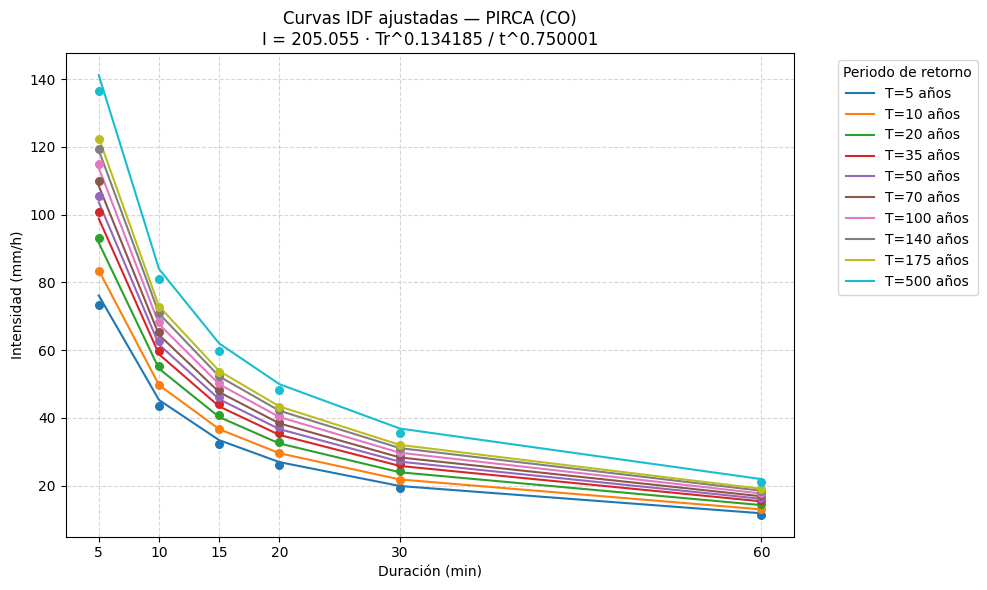

In [55]:
# Verificación: intensidades calculadas con la ecuación ajustada
intensidades_ajustadas = pd.DataFrame(index=duraciones)
intensidades_ajustadas.index.name = "Duración (min)"

for T in periodos:
    intensidades_ajustadas[f"T={int(T)} años"] = [
        round(K * (T ** m) / (t ** n), 4)
        for t in duraciones
    ]

# Gráfico comparativo: datos originales vs ecuación ajustada
plt.figure(figsize=(10, 6))
colores = plt.cm.tab10.colors

for i, col in enumerate(cols_validas):
    T = float(col.replace("T=", "").replace(" años", ""))
    plt.scatter(duraciones_grafico,
                intensidades_mm.loc[duraciones_grafico, col],
                color=colores[i % 10], s=30, zorder=5)
    plt.plot(duraciones_grafico,
             intensidades_ajustadas.loc[duraciones_grafico, col],
             color=colores[i % 10], linewidth=1.5,
             label=f"T={int(T)} años")

plt.title(f"Curvas IDF ajustadas — {estacion_e} ({categoria_e})\n"
          f"I = {K} · Tr^{m} / t^{n}")
plt.xlabel("Duración (min)")
plt.ylabel("Intensidad (mm/h)")
plt.xticks(duraciones_grafico)
plt.legend(title="Periodo de retorno", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(ubi_carpeta, "Curvas_IDF_ajustadas.pdf"), dpi=200)
plt.savefig(os.path.join(ubi_carpeta, "Curvas_IDF_ajustadas.png"), dpi=200)
plt.show()

# EXPORTACIÓN DE RESULTADOS A EXCEL

Se importa `openpyxl` con sus módulos de estilos y utilidades para
construir y formatear el archivo Excel de resultados. Asegúrate de
haberlo instalado previamente con:
```bash
pip install openpyxl
```

In [56]:
import openpyxl
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles.alignment import Alignment
from openpyxl.styles import Color,Font,Alignment,PatternFill,Border,Side,Protection

## Hoja 1 — Datos históricos de precipitación mensual

Se prepara la tabla `data` con los registros históricos de precipitación
mensual y máximos anuales para exportación. La columna `Max` se redondea
a 2 decimales y el índice `Año` se convierte en columna.

Completa manualmente las celdas de coordenadas (`LAT`, `LONG`, `ALT`) y ubicación (`DPTO`, `PROV`, `DIST`) con los metadatos de la estación.

In [57]:
tab_datos_estacion = data.copy()
tab_datos_estacion["Max"] = round(tab_datos_estacion["Max"], 2)
tab_datos_estacion.reset_index(inplace=True, drop=False)

In [58]:
# Crea el libro de trabajo y nombra la hoja activa con el código de la estación
wb = Workbook()
ws = wb.active
ws.title = estacion_e

# Calcula el rango de celdas según el tamaño de tab_datos_estacion
min_columna = 1
max_columna = min_columna + tab_datos_estacion.shape[1]
min_fila    = 1
max_fila    = min_fila + tab_datos_estacion.shape[0]

if max_columna > 26:
    Letra2 = max_columna - 26
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             "A" + str(chr(ord('@') + Letra2)) + str(max_fila)
else:
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             str(chr(ord('@') + max_columna)) + str(max_fila)

# Reemplaza pd.NA por None para compatibilidad con openpyxl
tab_datos_estacion = tab_datos_estacion.where(tab_datos_estacion.notna(), other=None)

# Escribe los datos y los desplaza 4 filas hacia abajo para el encabezado
for r in dataframe_to_rows(tab_datos_estacion, index=False, header=True):
    ws.append(r)

ws.move_range(Rango, rows=4, cols=1)
ws.column_dimensions['B'].width = 12

# Aplica alineación centrada a las filas de datos
for row in ws:
    for cell in row:
        if cell.row in range(5, 5 + max_fila):
            cell.alignment = Alignment(horizontal='center',
                                       vertical='center',
                                       wrap_text=False)

# Encabezado: nombre de estación y parámetro analizado
ws['B2'] = "ESTACION:"
ws['C2'] = estacion_e
ws['B3'] = "PARAMETRO:"
ws['C3'] = "PRECIPITACION MÁXIMA EN 24 HORAS (mm)"

# Coordenadas geográficas (completar manualmente)
ws['I2'] = "LAT:"
ws['I3'] = "LONG:"
ws['I4'] = "ALT:"

# Ubicación político-administrativa (completar manualmente)
ws['L2'] = "DPTO:"
ws['L3'] = "PROV:"
ws['L4'] = "DIST:"

# Guarda el archivo Excel en la carpeta de resultados
ruta_archivo_excel = os.path.join(ubi_carpeta, f'ANALISIS_ESTADISTICO_{estacion_e}.xlsx')
wb.save(ruta_archivo_excel)
wb.close()

## Hoja 2 — Serie de precipitaciones máximas anuales

Se exporta la tabla `precipitaciones_maximas` con la serie de precipitaciones
máximas en 24 horas, indicando para cada año el mes en que ocurrió el evento
máximo.

In [59]:
# Prepara la serie de precipitaciones máximas anuales para exportación
tab_pp_maximas = precipitaciones_maximas.copy()
tab_pp_maximas.reset_index(inplace=True, drop=False)

In [60]:
# Abre el archivo Excel existente y crea la hoja de precipitaciones máximas
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb.create_sheet("Precipitaciones_Maximas")

# Calcula el rango de celdas según el tamaño de tab_pp_maximas
min_columna = 1
max_columna = min_columna + tab_pp_maximas.shape[1]
min_fila    = 1
max_fila    = min_fila + tab_pp_maximas.shape[0]

if max_columna > 26:
    Letra2 = max_columna - 26
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             "A" + str(chr(ord('@') + Letra2)) + str(max_fila)
else:
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             str(chr(ord('@') + max_columna)) + str(max_fila)

# Escribe los datos y los desplaza 1 fila hacia abajo
for r in dataframe_to_rows(tab_pp_maximas, index=False, header=True):
    ws.append(r)

ws.move_range(Rango, rows=1, cols=1)

# Ajusta el ancho de columnas
ws.column_dimensions['D'].width = 12
ws.column_dimensions['E'].width = 20.57
ws.column_dimensions['F'].width = 29.57

# Aplica alineación centrada a las filas de datos
for row in ws:
    for cell in row:
        if cell.row in range(2, 2 + max_fila):
            cell.alignment = Alignment(horizontal='center',
                                       vertical='center',
                                       wrap_text=False)

wb.save(ruta_archivo_excel)
wb.close()

## Hoja 3 — Análisis exploratorio

Se preparan las tablas del análisis exploratorio para su exportación.
Esta hoja contendrá los estadísticos descriptivos y la tabla completa
del análisis exploratorio de la serie de máximos anuales.

In [61]:
tab_datos_dudosos_exp = tabla_datos_dudosos.copy()
tab_datos_dudosos_exp.reset_index(inplace=True, drop=False)

In [62]:
# Prepara la tabla del análisis exploratorio para exportación
tab_analisis_exploratorio = serie_pp.copy()
tab_analisis_exploratorio.reset_index(inplace=True, drop=False)

In [63]:
# Abre el archivo Excel y crea la hoja de análisis exploratorio
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb.create_sheet("Analisis_Exploratorio")

# Calcula el rango de celdas según el tamaño de tab_datos_dudosos_exp
min_columna = 1
max_columna = min_columna + tab_datos_dudosos_exp.shape[1]
min_fila    = 1
max_fila    = min_fila + tab_datos_dudosos_exp.shape[0]

if max_columna > 26:
    Letra2 = max_columna - 26
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             "A" + str(chr(ord('@') + Letra2)) + str(max_fila)
else:
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             str(chr(ord('@') + max_columna)) + str(max_fila)

# Escribe tab_datos_dudosos_exp y la posiciona en la hoja
for r in dataframe_to_rows(tab_datos_dudosos_exp, index=False, header=True):
    ws.append(r)

ws.move_range(Rango, rows=2, cols=6)
ws.column_dimensions['G'].width = 18.0

wb.save(ruta_archivo_excel)
wb.close()

In [64]:
# Abre la hoja existente y agrega la tabla del análisis exploratorio
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb["Analisis_Exploratorio"]

# Calcula el rango de celdas según el tamaño de tab_analisis_exploratorio
min_columna = 1
max_columna = min_columna + tab_analisis_exploratorio.shape[1]
min_fila    = 12
max_fila    = min_fila + tab_analisis_exploratorio.shape[0] + 1

if max_columna > 26:
    Letra2 = max_columna - 26
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             "A" + str(chr(ord('@') + Letra2)) + str(max_fila)
else:
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             str(chr(ord('@') + max_columna)) + str(max_fila)

# Escribe tab_analisis_exploratorio y la posiciona en la hoja
for r in dataframe_to_rows(tab_analisis_exploratorio, index=False, header=True):
    ws.append(r)

ws.move_range(Rango, rows=-10, cols=1)

# Ajusta el ancho de columnas
ws.column_dimensions['D'].width = 20.57
ws.column_dimensions['E'].width = 26.14

# Aplica alineación centrada a las filas de datos
for row in ws:
    for cell in row:
        if cell.row in range(2, 2 + max_fila):
            cell.alignment = Alignment(horizontal='center',
                                       vertical='center',
                                       wrap_text=False)

wb.save(ruta_archivo_excel)
wb.close()

## Hoja 4 — Prueba de bondad de ajuste

Se prepara la tabla de la prueba de Kolmogorov-Smirnov para exportación.
Se eliminan las columnas auxiliares de transformación logarítmica y se
redondean todos los valores a 4 decimales.

In [65]:
# Prepara la tabla de la prueba de bondad de ajuste para exportación
tab_prueba_bondad = tabla_bondad.copy()
tab_prueba_bondad = round(tab_prueba_bondad, 4)
tab_prueba_bondad = tab_prueba_bondad.drop(['Ln (Xm)', 'Ln (Xm-Xo)'], axis=1)
tab_prueba_bondad.reset_index(inplace=True, drop=False)

In [66]:
# ── PASO 1: Crea la hoja y escribe tabla_parametros ──────────────
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb.create_sheet("Prueba_de_Bondad")

fila_params = 10
col_params  = 22  # columna V (cols=21 del original)

for i, r in enumerate(dataframe_to_rows(tabla_parametros, index=True, header=True)):
    for j, val in enumerate(r):
        ws.cell(row=fila_params + i, column=col_params + j).value = val
        ws.cell(row=fila_params + i, column=col_params + j).alignment = \
            Alignment(horizontal='center', vertical='center', wrap_text=False)

wb.save(ruta_archivo_excel)
wb.close()

In [67]:
# ── PASO 2: Escribe los datos de tab_prueba_bondad ───────────────
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb["Prueba_de_Bondad"]

fila_datos = 12  # inicia en fila 12, columna B
col_datos  = 2

for i, r in enumerate(dataframe_to_rows(tab_prueba_bondad, index=False, header=False)):
    for j, val in enumerate(r):
        ws.cell(row=fila_datos + i, column=col_datos + j).value = val
        ws.cell(row=fila_datos + i, column=col_datos + j).alignment = \
            Alignment(horizontal='center', vertical='center', wrap_text=False)

ws.column_dimensions['A'].width = 4.00
ws.column_dimensions['U'].width = 4.00

wb.save(ruta_archivo_excel)
wb.close()

In [68]:
# ── PASO 3: Encabezados de columnas ─────────────────────────────
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb["Prueba_de_Bondad"]

# Encabezados fijos
ws['B10'] = "m"
ws.merge_cells('B10:B11')
ws['B10'].alignment = Alignment(horizontal='center', vertical='center')

ws['C10'] = "Xm (mm)"
ws.merge_cells('C10:C11')
ws['C10'].alignment = Alignment(horizontal='center', vertical='center')

ws['D10'] = "Fo (Xm)"
ws.merge_cells('D10:D11')
ws['D10'].alignment = Alignment(horizontal='center', vertical='center')

# Genera exactamente un par de columnas por distribución
lista_distribuciones = list(tabla_parametros.index)
n_distribuciones     = len(lista_distribuciones)
cols_encabezado      = [5 + i * 2 for i in range(n_distribuciones)]

for let in cols_encabezado:
    par_let   = str(chr(ord('@') + let))
    par_let_s = str(chr(ord('@') + let + 1))
    ws.column_dimensions[par_let].width   = 7.00
    ws.column_dimensions[par_let_s].width = 15.50
    ws[par_let + "11"]   = 'F(Xm)'
    ws[par_let_s + "11"] = '|Fo(Xm)-F(Xm)|'

# Aplica alineación centrada
for row in ws:
    for cell in row:
        if cell.row in range(10, 12 + tab_prueba_bondad.shape[0]):
            cell.alignment = Alignment(horizontal='center',
                                       vertical='center',
                                       wrap_text=False)

# Escribe el nombre de cada distribución fusionando sus dos columnas directamente
for i, col in enumerate(range(5, 5 + n_distribuciones * 2, 2)):
    letra   = str(chr(ord('@') + col))
    letra_s = str(chr(ord('@') + col + 1))
    ws[letra + "10"] = lista_distribuciones[i]
    ws.merge_cells(letra + "10:" + letra_s + "10")
    ws[letra + "10"].alignment = Alignment(horizontal='center', vertical='center')

wb.save(ruta_archivo_excel)
wb.close()

In [69]:
# ── PASO 4: Encabezado informativo ──────────────────────────────
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb["Prueba_de_Bondad"]

# Título principal
ws['B2'] = "RESULTADOS DE LA PRUEBA DE BONDAD DE AJUSTE — KOLMOGOROV-SMIRNOV"
ws.merge_cells('B2:T2')
ws['B2'].alignment = Alignment(horizontal='center', vertical='center')

# Nombre de la estación
ws['B4'] = f"ESTACIÓN: {estacion_e}"
ws.merge_cells('B4:T4')
ws['B4'].alignment = Alignment(horizontal='center', vertical='center')

# Parámetros de la prueba
ws['B6'] = "Número de datos ="
ws['B7'] = "Valor crítico tabular ∆₀ ="
ws['B8'] = "Nivel de significación ="
ws['B6'].alignment = Alignment(horizontal='left', vertical='center')
ws['B7'].alignment = Alignment(horizontal='left', vertical='center')
ws['B8'].alignment = Alignment(horizontal='left', vertical='center')

ws['E6'] = tabla_bondad.shape[0]
ws['E7'] = D_critico
ws['E8'] = nivel_significacion
ws['E6'].alignment = Alignment(horizontal='right', vertical='center')
ws['E7'].alignment = Alignment(horizontal='right', vertical='center')
ws['E8'].alignment = Alignment(horizontal='right', vertical='center')

wb.save(ruta_archivo_excel)
wb.close()

## Hoja 5 — Análisis de frecuencia

Se prepara la serie depurada de precipitaciones máximas para exportación.

In [70]:
# Prepara la serie de frecuencias para exportación
tab_analisis_frecuencia = serie_frecuencia.copy()
tab_analisis_frecuencia = tab_analisis_frecuencia.drop(["Ln (Ppm-Ppo)"], axis=1)
tab_analisis_frecuencia["Log10 Pp max. 24 horas (mm)"] = round(
    tab_analisis_frecuencia["Log10 Pp max. 24 horas (mm)"], 2
)

In [71]:
# Prepara la tabla de precipitaciones de diseño por distribución para exportación
tab_dist_frecuencias = dist_frecuencias.copy()
tab_dist_frecuencias["P"]                          = round(tab_dist_frecuencias["P"], 4)
tab_dist_frecuencias["Normal"]                     = round(tab_dist_frecuencias["Normal"], 2)
tab_dist_frecuencias["Log-Normal 2 parámetros"]    = round(tab_dist_frecuencias["Log-Normal 2 parámetros"], 2)
tab_dist_frecuencias["Log-Normal 3 parámetros"]    = round(tab_dist_frecuencias["Log-Normal 3 parámetros"], 2)
tab_dist_frecuencias["Pearson tipo III"]           = round(tab_dist_frecuencias["Pearson tipo III"], 2)
tab_dist_frecuencias["Log-Pearson tipo III"]       = round(tab_dist_frecuencias["Log-Pearson tipo III"], 2)
tab_dist_frecuencias["Gumbel"]                     = round(tab_dist_frecuencias["Gumbel"], 2)

In [72]:
# Abre el archivo Excel y crea la hoja de análisis de frecuencia
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb.create_sheet("Analisis_de_Frecuencia")

# Calcula el rango de celdas según el tamaño de tab_dist_frecuencias
fila_inicial = 1
min_columna  = 1
max_columna  = min_columna + tab_dist_frecuencias.shape[1]
min_fila     = fila_inicial
max_fila     = min_fila + tab_dist_frecuencias.shape[0]

if max_columna > 26:
    Letra2 = max_columna - 26
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             "A" + str(chr(ord('@') + Letra2)) + str(max_fila)
else:
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             str(chr(ord('@') + max_columna)) + str(max_fila)

# Escribe los datos con encabezado
for r in dataframe_to_rows(tab_dist_frecuencias, index=False, header=True):
    ws.append(r)

# Aplica alineación centrada a todas las filas de datos
for row in ws:
    for cell in row:
        if cell.row in range(1, fila_inicial + max_fila):
            cell.alignment = Alignment(horizontal='center',
                                       vertical='center',
                                       wrap_text=False)

# Ajusta el ancho de columnas
ws.column_dimensions['I'].width = 23.00
ws.column_dimensions['J'].width = 23.00
ws.column_dimensions['K'].width = 19.50
ws.column_dimensions['L'].width = 19.50
ws.column_dimensions['M'].width = 18.00
ws.column_dimensions['N'].width =  8.00
ws.column_dimensions['O'].width = 11.00

ws.move_range(Rango, rows=1, cols=5)

wb.save(ruta_archivo_excel)
wb.close()

In [73]:
# Agrega la serie de frecuencias a la hoja de análisis de frecuencia
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb["Analisis_de_Frecuencia"]

# Posiciona la tabla debajo de tab_dist_frecuencias
fila_inicial = 1 + tab_dist_frecuencias.shape[0]
min_columna  = 1
max_columna  = min_columna + tab_analisis_frecuencia.shape[1]
min_fila     = fila_inicial
max_fila     = 2 + min_fila + tab_analisis_frecuencia.shape[0]

if max_columna > 26:
    Letra2 = max_columna - 26
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             "A" + str(chr(ord('@') + Letra2)) + str(max_fila)
else:
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             str(chr(ord('@') + max_columna)) + str(max_fila)

# Escribe los datos con encabezado
for r in dataframe_to_rows(tab_analisis_frecuencia, index=False, header=True):
    ws.append(r)

# Aplica alineación centrada a todas las filas de datos
for row in ws:
    for cell in row:
        if cell.row in range(1, fila_inicial + max_fila):
            cell.alignment = Alignment(horizontal='center',
                                       vertical='center',
                                       wrap_text=False)

# Ajusta el ancho de columnas
ws.column_dimensions['C'].width = 21.00
ws.column_dimensions['D'].width = 26.50

ws.move_range(Rango, rows=-10, cols=1)

wb.save(ruta_archivo_excel)
wb.close()

## Hoja 6 — Resumen K-S y probabilidades de excedencia

Se prepara la tabla resumen de la prueba de Kolmogorov-Smirnov para
exportación.

In [74]:
# Prepara el resumen de la prueba K-S para exportación
tab_resumen_ks = tabla_resumen_ks.copy()
tab_resumen_ks["Delta teórico (Δ)"] = round(tab_resumen_ks["Delta teórico (Δ)"], 4)

In [75]:
# Abre el archivo Excel y crea la hoja de resultados Kolmogorov-Smirnov
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb.create_sheet("Kolmogorov_Smirnov")

# Calcula el rango de celdas según el tamaño de tab_resumen_ks
fila_inicial = 1
min_columna  = 1
max_columna  = min_columna + tab_resumen_ks.shape[1]
min_fila     = fila_inicial
max_fila     = min_fila + tab_resumen_ks.shape[0]

if max_columna > 26:
    Letra2 = max_columna - 26
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             "A" + str(chr(ord('@') + Letra2)) + str(max_fila)
else:
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             str(chr(ord('@') + max_columna)) + str(max_fila)

# Escribe los datos con encabezado
for r in dataframe_to_rows(tab_resumen_ks, index=False, header=True):
    ws.append(r)

# Aplica alineación centrada a todas las filas de datos
for row in ws:
    for cell in row:
        if cell.row in range(1, fila_inicial + max_fila):
            cell.alignment = Alignment(horizontal='center',
                                       vertical='center',
                                       wrap_text=False)

# Ajusta el ancho de columnas
ws.column_dimensions['G'].width = 28.50
ws.column_dimensions['H'].width = 19.50
ws.column_dimensions['I'].width = 23.50
ws.column_dimensions['J'].width = 22.50
ws.column_dimensions['K'].width = 15.00
ws.column_dimensions['L'].width = 14.50
ws.column_dimensions['M'].width = 11.50

ws.move_range(Rango, rows=1, cols=6)

wb.save(ruta_archivo_excel)
wb.close()

In [76]:
# Prepara la tabla de probabilidades de excedencia para exportación
tab_prob_excedencia = prob_excedencia.copy()
tab_prob_excedencia["P"]                        = round(tab_prob_excedencia["P"], 4)
tab_prob_excedencia[distribucion_elegida]        = round(tab_prob_excedencia[distribucion_elegida], 2)
tab_prob_excedencia["Prob. de excedencia"]       = round(tab_prob_excedencia["Prob. de excedencia"], 4)
tab_prob_excedencia

,T (años),P,Gumbel,Prob. de excedencia
0,500,0.0020,46.83,0.9980
1,175,0.0057,41.99,0.9943
2,140,0.0071,40.97,0.9929
3,100,0.0100,39.41,0.9900
4,70,0.0143,37.77,0.9857
5,50,0.0200,36.21,0.9800
6,35,0.0286,34.55,0.9714
7,20,0.0500,31.93,0.9500
8,10,0.1000,28.62,0.9000
9,5,0.2000,25.17,0.8000


In [77]:
# Agrega la tabla de probabilidades de excedencia a la hoja Kolmogorov_Smirnov
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb["Kolmogorov_Smirnov"]

# Posiciona la tabla debajo de tab_resumen_ks
fila_inicial = 1 + tab_resumen_ks.shape[0]
min_columna  = 1
max_columna  = min_columna + tab_prob_excedencia.shape[1]
min_fila     = fila_inicial
max_fila     = 2 + min_fila + tab_prob_excedencia.shape[0]

if max_columna > 26:
    Letra2 = max_columna - 26
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             "A" + str(chr(ord('@') + Letra2)) + str(max_fila)
else:
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             str(chr(ord('@') + max_columna)) + str(max_fila)

# Escribe los datos con encabezado
for r in dataframe_to_rows(tab_prob_excedencia, index=False, header=True):
    ws.append(r)

# Aplica alineación centrada a todas las filas de datos
for row in ws:
    for cell in row:
        if cell.row in range(1, fila_inicial + max_fila):
            cell.alignment = Alignment(horizontal='center',
                                       vertical='center',
                                       wrap_text=False)

ws.move_range(Rango, rows=-tab_resumen_ks.shape[0], cols=1)

# Ajusta el ancho de columnas
ws.column_dimensions['D'].width = 23.50
ws.column_dimensions['E'].width = 18.50

wb.save(ruta_archivo_excel)
wb.close()

## Hoja 7 — Intensidades y precipitaciones de diseño IDF

Se preparan y exportan las tablas de intensidades máximas (mm/h) y
precipitaciones acumuladas (mm) para cada duración y periodo de retorno,
calculadas mediante el método de Dick y Peschke.

In [78]:
# Prepara las tablas de intensidades y precipitaciones IDF para exportación
tab_intensidades_idf = intensidades_mm.copy()
for col in tab_intensidades_idf.columns:
    tab_intensidades_idf[col] = round(tab_intensidades_idf[col], 2)

tab_precipitaciones_idf = precipitaciones_mm.copy()
for col in tab_precipitaciones_idf.columns:
    tab_precipitaciones_idf[col] = round(tab_precipitaciones_idf[col], 2)

In [79]:
# Abre el archivo Excel y crea la hoja de intensidades máximas IDF
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb.create_sheet("Intensidades_IDF")

# Aplana el índice para evitar desfases al exportar
tab_precipitaciones_exp = tab_precipitaciones_idf.reset_index()
tab_intensidades_exp    = tab_intensidades_idf.reset_index()

# ── TABLA 1: PRECIPITACIONES ──────────────────────
# Título
ws['A2'] = f"PRECIPITACIONES DE DISEÑO POR DURACIÓN (mm) — Método Dick y Peschke — {estacion_e}"
ws['A2'].alignment = Alignment(horizontal='center', vertical='center')

# Escribe datos de precipitaciones a partir de la fila 3
fila_pp = 3
for i, r in enumerate(dataframe_to_rows(tab_precipitaciones_exp,
                                         index=False, header=True)):
    for j, val in enumerate(r):
        ws.cell(row=fila_pp + i, column=j + 1).value = val
        ws.cell(row=fila_pp + i, column=j + 1).alignment = \
            Alignment(horizontal='center', vertical='center', wrap_text=False)

ws.column_dimensions['A'].width = 14.40

# ── TABLA 2: INTENSIDADES ─────────────────────────
fila_int = fila_pp + tab_precipitaciones_exp.shape[0] + 3

# Título
ws.cell(row=fila_int, column=1).value = \
    f"INTENSIDADES MÁXIMAS DE DISEÑO (mm/h) — {estacion_e}"
ws.cell(row=fila_int, column=1).alignment = \
    Alignment(horizontal='center', vertical='center')

# Escribe datos de intensidades
for i, r in enumerate(dataframe_to_rows(tab_intensidades_exp,
                                         index=False, header=True)):
    for j, val in enumerate(r):
        ws.cell(row=fila_int + 1 + i, column=j + 1).value = val
        ws.cell(row=fila_int + 1 + i, column=j + 1).alignment = \
            Alignment(horizontal='center', vertical='center', wrap_text=False)

ws.column_dimensions['A'].width = 14.40

wb.save(ruta_archivo_excel)
wb.close()

## Hoja 8 — Regresión lineal múltiple
Se preparan y exportan los datos de entrada de la regresión lineal múltiple
y sus resultados. Ambas tablas se ubican en la misma hoja para facilitar
la revisión de los coeficientes `K`, `m` y `n` de la ecuación IDF.

In [80]:
# Prepara los datos de entrada de la regresión para exportación
tab_datos_regresion = df_regresion.copy()
tab_datos_regresion["Log(I)"] = round(tab_datos_regresion["Log(I)"], 4)
tab_datos_regresion["Log(T)"] = round(tab_datos_regresion["Log(T)"], 4)
tab_datos_regresion["Log(t)"] = round(tab_datos_regresion["Log(t)"], 4)

In [81]:
# Prepara los resultados de la regresión para exportación
tab_resultados_regresion = resultados_regresion.copy()
tab_resultados_regresion["Valor"] = round(tab_resultados_regresion["Valor"], 4)

In [82]:
# Abre el archivo Excel y crea la hoja de regresión lineal múltiple
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb.create_sheet("Regresion_IDF")

# Calcula el rango según el tamaño de tab_datos_regresion
fila_inicial = 1
min_columna  = 1
max_columna  = min_columna + tab_datos_regresion.shape[1]
min_fila     = fila_inicial
max_fila     = min_fila + tab_datos_regresion.shape[0]

if max_columna > 26:
    Letra2 = max_columna - 26
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             "A" + str(chr(ord('@') + Letra2)) + str(max_fila)
else:
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             str(chr(ord('@') + max_columna)) + str(max_fila)

# Escribe tab_datos_regresion con encabezado
for r in dataframe_to_rows(tab_datos_regresion, index=False, header=True):
    ws.append(r)

# Aplica alineación centrada
for row in ws:
    for cell in row:
        if cell.row in range(1, fila_inicial + max_fila):
            cell.alignment = Alignment(horizontal='center',
                                       vertical='center',
                                       wrap_text=False)

ws.move_range(Rango, rows=1, cols=tab_resultados_regresion.shape[1] + 3)

wb.save(ruta_archivo_excel)
wb.close()

In [83]:
# Agrega los resultados de la regresión a la hoja Regresion_IDF
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb["Regresion_IDF"]

# Posiciona tab_resultados_regresion al lado de tab_datos_regresion
fila_inicial = 1 + tab_datos_regresion.shape[0]
min_columna  = 1
max_columna  = min_columna + tab_resultados_regresion.shape[1]
min_fila     = fila_inicial
max_fila     = 2 + min_fila + tab_resultados_regresion.shape[0]

if max_columna > 26:
    Letra2 = max_columna - 26
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             "A" + str(chr(ord('@') + Letra2)) + str(max_fila)
else:
    Rango  = str(chr(ord('@') + min_columna)) + str(min_fila) + ":" + \
             str(chr(ord('@') + max_columna)) + str(max_fila)

# Escribe con índice y sin encabezado (el índice contiene los nombres de parámetros)
for r in dataframe_to_rows(tab_resultados_regresion, index=True, header=False):
    ws.append(r)

# Aplica alineación centrada
for row in ws:
    for cell in row:
        if cell.row in range(1, fila_inicial + max_fila):
            cell.alignment = Alignment(horizontal='center',
                                       vertical='center',
                                       wrap_text=False)

ws.move_range(Rango, rows=-tab_datos_regresion.shape[0], cols=1)
ws.column_dimensions['B'].width = 30.30

wb.save(ruta_archivo_excel)
wb.close()

In [84]:
# Agrega la ecuación IDF y parámetros al final de la hoja Regresion_IDF
wb = openpyxl.load_workbook(ruta_archivo_excel)
ws = wb["Regresion_IDF"]

# Fila de inicio para la ecuación (debajo de los resultados)
fila_ec = 2 + tab_resultados_regresion.shape[0] + 3

# Título de la sección
ws.cell(row=fila_ec, column=2).value = "PARÁMETROS Y ECUACIÓN IDF AJUSTADA"
ws.cell(row=fila_ec, column=2).alignment = Alignment(horizontal='center', vertical='center')

# Parámetros K, m, n
ws.cell(row=fila_ec + 2, column=2).value = "Parámetro"
ws.cell(row=fila_ec + 2, column=3).value = "Valor"
ws.cell(row=fila_ec + 2, column=2).alignment = Alignment(horizontal='center', vertical='center')
ws.cell(row=fila_ec + 2, column=3).alignment = Alignment(horizontal='center', vertical='center')

ws.cell(row=fila_ec + 3, column=2).value = "K"
ws.cell(row=fila_ec + 3, column=3).value = K
ws.cell(row=fila_ec + 4, column=2).value = "m"
ws.cell(row=fila_ec + 4, column=3).value = m
ws.cell(row=fila_ec + 5, column=2).value = "n"
ws.cell(row=fila_ec + 5, column=3).value = n

for fila in range(fila_ec + 3, fila_ec + 6):
    for col in [2, 3]:
        ws.cell(row=fila, column=col).alignment = \
            Alignment(horizontal='center', vertical='center')

# Ecuación IDF
ws.cell(row=fila_ec + 7, column=2).value = "Ecuación IDF:"
ws.cell(row=fila_ec + 7, column=3).value = f"I = {K} · Tr^{m} / t^{n}"
ws.cell(row=fila_ec + 8, column=2).value = "Donde:"
ws.cell(row=fila_ec + 9, column=2).value = "I  = Intensidad máxima (mm/h)"
ws.cell(row=fila_ec + 10, column=2).value = "Tr = Periodo de retorno (años)"
ws.cell(row=fila_ec + 11, column=2).value = "t  = Duración de la lluvia (minutos)"

for fila in range(fila_ec + 7, fila_ec + 12):
    for col in [2, 3]:
        ws.cell(row=fila, column=col).alignment = \
            Alignment(horizontal='left', vertical='center')

ws.column_dimensions['B'].width = 35.00
ws.column_dimensions['C'].width = 30.00

wb.save(ruta_archivo_excel)
wb.close()